# Stage 1: AM + ESM-2 Scalar Ensemble for CYP2C9 Activity Prediction

Combines two complementary scalar signals to improve prediction of CYP2C9 functional activity (CLICK-seq), with a focus on variants that AlphaMissense classifies as **ambiguous**.

| Signal | Source | Higher value means |
|---|---|---|
| `am_score` | AlphaMissense | More pathogenic |
| `esm2_mmp` | ESM-2 masked marginal log-likelihood (Δ log P mutant − WT) | More evolutionarily tolerated |

**Hypothesis**: ESM-2 carries complementary evolutionary fitness signal that compensates where AM's structural signal is weak (ambiguous variants).

## Required input files

All paths below are relative to this notebook, i.e. `DATA_DIR = '../data'`:

| Path | Description |
|---|---|
| `AlphaMissense-Search-P11712.tsv` | AlphaMissense pathogenicity score and class for every CYP2C9 (UniProt P11712) missense variant. |
| `cyp2c9.csv` | Deep mutational scanning data: VAMP-seq abundance and CLICK-seq activity scores for CYP2C9 variants. |
| `masked_marginal_prob.json` | ESM-2 masked-marginal log-likelihood ratio (Δ log P, mutant vs. WT) per CYP2C9 variant, keyed as `P11712_<3-letter mutation>`. |
| `rep_matrix_files.txt` | Ordered list of `P11712_<mutation>.pt` filenames giving the row order of `rep_matrix.npy`. |
| `rep_matrix.npy` | Per-residue ESM-2 embeddings for N=~8000 CYP2C9 variants, shape `(N, 490, 1280)` (~40 GB; loaded via `mmap_mode='r'`, never fully read into memory). |
| `clinvar_cyp2c9.txt` | ClinVar tab-delimited variant summary for CYP2C9; used as an independent clinical validation set. |
| `pharmvar_cyp2c9_missense_mutations_single.csv` | PharmVar missense allele definitions and functional status for CYP2C9; used as a second independent validation set. |


In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit, minimize
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.isotonic import IsotonicRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import (
    r2_score, roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, accuracy_score, f1_score, matthews_corrcoef,
)
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text


# ── Figure defaults ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         150,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'legend.frameon':      True,
    'legend.framealpha':   0.85,
    'legend.facecolor':    'white',
    'legend.edgecolor':    '0.8',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.2,
})

DATA_DIR    = '../data'
CLASS_ORDER = ['likely_benign', 'ambiguous', 'likely_pathogenic']
PALETTE     = {'likely_benign': '#0072B2', 'ambiguous': '#E69F00', 'likely_pathogenic': '#D55E00'}

class MonotoneSigmoid(BaseEstimator, RegressorMixin):
    """4-parameter logistic, monotone increasing: higher MMP -> higher activity."""
    @staticmethod
    def _sigmoid(x, L, k, x0, b):
        return L / (1 + np.exp(-k * (x - x0))) + b

    def fit(self, X, y):
        X = np.asarray(X).ravel()
        y = np.asarray(y)
        p0 = [float(y.max() - y.min()), 1.0, float(np.median(X)), float(y.min())]
        try:
            self.popt_, _ = curve_fit(
                self._sigmoid, X, y, p0=p0,
                bounds=([0, 1e-3, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
                maxfev=20_000
            )
        except RuntimeError:
            self.popt_ = np.array(p0)
        return self

    def predict(self, X):
        return self._sigmoid(np.asarray(X).ravel(), *self.popt_)

class CalibratedEnsemble(BaseEstimator, RegressorMixin):
    """Ridge on calibrated [am_activity, esm2_activity]; inner 4-fold OOF avoids leakage."""
    def fit(self, X, y):
        X_am, X_esm = X[:, 0], X[:, 1]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        X_meta = np.column_stack([am_oof, esm_oof])
        self.ridge_ = Pipeline([('scaler', StandardScaler()),
                                 ('ridge',  RidgeCV(alphas=np.logspace(-3, 3, 50)))]).fit(X_meta, y)
        return self

    def predict(self, X):
        X_am, X_esm = X[:, 0], X[:, 1]
        return self.ridge_.predict(np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm)
        ]))


def _fit_simplex_weights(X_meta, y):
    """Non-negative weights summing to 1 that minimise MSE (simplex regression)."""
    n = X_meta.shape[1]
    res = minimize(
        lambda w: np.mean((X_meta @ w - y) ** 2),
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, None)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}
    )
    return res.x if res.success else np.ones(n) / n


class ConstrainedEnsemble(BaseEstimator, RegressorMixin):
    """Simplex-constrained weighted average of calibrated [am_activity, esm2_activity].
    Weights >= 0 and sum to 1; inner 4-fold OOF avoids leakage."""
    def fit(self, X, y):
        X_am, X_esm = X[:, 0], X[:, 1]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        self.weights_ = _fit_simplex_weights(np.column_stack([am_oof, esm_oof]), y)
        return self

    def predict(self, X):
        X_am, X_esm = X[:, 0], X[:, 1]
        return np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm)
        ]) @ self.weights_


class ConstrainedEnsemblePlusKNN(BaseEstimator, RegressorMixin):
    """Simplex-constrained weighted average of [am_activity, esm2_activity, knn_activity].
    Weights >= 0 and sum to 1; inner 4-fold OOF avoids leakage."""
    def __init__(self, k=5):
        self.k = k

    def _make_knn(self):
        return Pipeline([('scaler', StandardScaler()),
                         ('knn',   KNeighborsRegressor(n_neighbors=self.k,
                                                        weights='distance', metric='cosine'))])

    def fit(self, X, y):
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        self.knn_     = self._make_knn().fit(X_embed, y)
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        knn_oof = cross_val_predict(
            self._make_knn(), X_embed, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        self.weights_ = _fit_simplex_weights(np.column_stack([am_oof, esm_oof, knn_oof]), y)
        return self

    def predict(self, X):
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:]
        return np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm),
            self.knn_.predict(X_embed)
        ]) @ self.weights_


## Load & merge data

In [2]:
# ── AlphaMissense ─────────────────────────────────────────────────────────────
am = pd.read_csv(f'{DATA_DIR}/AlphaMissense-Search-P11712.tsv', sep='\t')
am.columns = am.columns.str.lstrip('# ')
am = am.rename(columns={
    'a.a.1': 'ref', 'position': 'pos', 'a.a.2': 'alt',
    'pathogenicity score': 'am_score', 'pathogenicity class': 'am_class'
})

# ── ESM-2 masked marginal log-likelihood ──────────────────────────────────────
with open(f'{DATA_DIR}/masked_marginal_prob.json') as f:
    esm2_raw = json.load(f)

esm2 = pd.DataFrame(list(esm2_raw.items()), columns=['key', 'esm2_mmp'])
esm2['mutation'] = esm2['key'].str.replace('P11712_', '', regex=False)
esm2 = esm2[['mutation', 'esm2_mmp']]

# ── DMS activity scores ───────────────────────────────────────────────────────
dms = pd.read_csv(f'{DATA_DIR}/cyp2c9.csv', index_col=0)
dms_ms = dms[dms['alt'] != '='].copy()
dms_ms['pos'] = dms_ms['pos'].astype(int)

# ── Three-way merge ───────────────────────────────────────────────────────────
merged = (
    dms_ms
    .merge(esm2, on='mutation', how='inner')
    .merge(am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='inner')
)

print(f'Merged variants:  {len(merged):,}')
print(f'With click-seq:   {merged["click-seq_score"].notna().sum():,}')
print(f'\nAM class breakdown:')
print(merged['am_class'].value_counts().to_string())
merged.head()

Merged variants:  8,097
With click-seq:   6,145

AM class breakdown:
am_class
likely_pathogenic    3296
likely_benign        3255
ambiguous            1546


,mutation,protein,ref,pos,alt,vamp-seq_score,click-seq_score,vamp-seq_score_norm,click-seq_score_norm,esm2_mmp,am_score,am_class
0,Ala103Arg,CYP2C9,A,103,R,0.895387,0.745012,0.901634,0.756173,-1.865662,0.5645,likely_pathogenic
1,Ala103Asp,CYP2C9,A,103,D,0.784961,1.179110,0.790437,1.196774,-3.777131,0.6448,likely_pathogenic
2,Ala103Cys,CYP2C9,A,103,C,NaN,1.067052,NaN,1.083038,-2.420961,0.4753,ambiguous
3,Ala103Gln,CYP2C9,A,103,Q,1.014394,1.213731,1.021471,1.231914,-1.151646,0.4662,ambiguous
4,Ala103Glu,CYP2C9,A,103,E,NaN,1.242510,NaN,1.261124,-3.267833,0.4906,ambiguous


In [3]:
# ── ClinVar CYP2C9 variants ───────────────────────────────────────────────────
clinvar = pd.read_csv(f'{DATA_DIR}/clinvar_cyp2c9.txt', sep='\t')

def parse_mut(s):
    m = re.match(r'^([A-Z])(\d+)([A-Z*])$', str(s))
    return (m.group(1), int(m.group(2)), m.group(3)) if m else None

_cv = clinvar[['Protein change', 'Germline classification', 'Molecular consequence', 'Condition(s)']].rename(columns={
    'Protein change': 'mutation',
    'Germline classification': 'functional_effect',
    'Molecular consequence': 'mol_consequence',
    'Condition(s)': 'condition'
})
result = _cv[
    _cv['mutation'].notna() & _cv['mutation'].str.strip().ne('') &
    _cv['functional_effect'].notna() & _cv['functional_effect'].str.strip().ne('')
].copy()

benign = result.loc[
    result['functional_effect'].str.contains('Benign', case=False, na=False) &
    ~result['functional_effect'].str.contains('Likely benign', case=False, na=False),
    'mutation'
].tolist()
likely_benign = result.loc[
    result['functional_effect'].str.contains('Likely benign', case=False, na=False),
    'mutation'
].tolist()
pathogenic = result.loc[
    result['functional_effect'].str.contains('Pathogenic', case=False, na=False) &
    ~result['functional_effect'].str.contains('Likely pathogenic', case=False, na=False),
    'mutation'
].tolist()
likely_pathogenic = result.loc[
    result['functional_effect'].str.contains('Likely pathogenic', case=False, na=False),
    'mutation'
].tolist()
uncertain_significance = result.loc[
    result['functional_effect'].str.contains('Uncertain significance', case=False, na=False),
    'mutation'
].tolist()

clinvar_rpa = set()
for _m in benign + likely_benign + pathogenic + likely_pathogenic + uncertain_significance:
    _p = parse_mut(_m)
    if _p:
        clinvar_rpa.add(_p)

print(f'ClinVar: {len(result)} variants with mutation+functional_effect, {len(clinvar_rpa)} unique positions')
print(f'  Benign: {len(benign)}')
print(f'  Likely benign: {len(likely_benign)}')
print(f'  Pathogenic: {len(pathogenic)}')
print(f'  Likely pathogenic: {len(likely_pathogenic)}')
print(f'  Uncertain significance: {len(uncertain_significance)}')


ClinVar: 50 variants with mutation+functional_effect, 42 unique positions
  Benign: 2
  Likely benign: 5
  Pathogenic: 1
  Likely pathogenic: 0
  Uncertain significance: 34


## Feature overview: correlation and complementarity

Total variants with all features: 6,145
Spearman(am_score, esm2_mmp) = -0.797  (shared variance ≈ 63.518%)


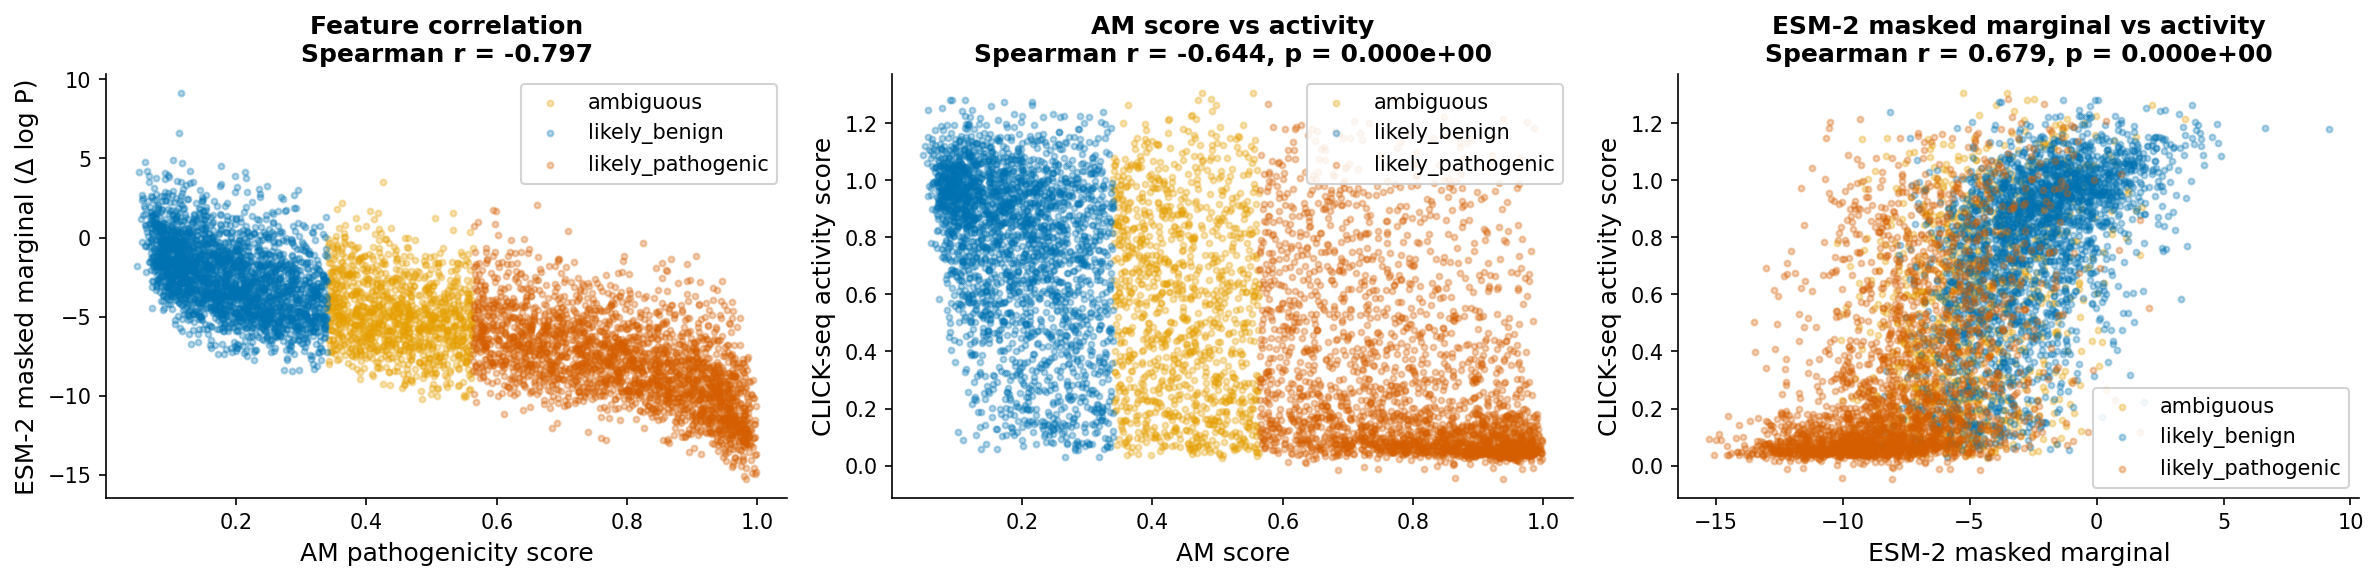

In [4]:
fit = merged[['mutation', 'ref', 'pos', 'alt', 'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
print(f'Total variants with all features: {len(fit):,}')

r_feat, _ = stats.spearmanr(fit['am_score'], fit['esm2_mmp'])
print(f'Spearman(am_score, esm2_mmp) = {r_feat:.3f}  '
      f'(shared variance ≈ {r_feat**2*100:.3f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Feature–feature scatter
ax = axes[0]
for cls, grp in fit.groupby('am_class'):
    ax.scatter(grp['am_score'], grp['esm2_mmp'], color=PALETTE[cls],
               alpha=0.3, s=8, label=cls, rasterized=True)
ax.set_xlabel('AM pathogenicity score', fontsize=12)
ax.set_ylabel('ESM-2 masked marginal (Δ log P)', fontsize=12)
ax.set_title(f'Feature correlation\nSpearman r = {r_feat:.3f}', fontsize=12)
ax.legend(fontsize=10)

# Each feature vs click-seq
for ax, feat, label in zip(axes[1:],
                            ['am_score', 'esm2_mmp'],
                            ['AM score', 'ESM-2 masked marginal']):
    for cls, grp in fit.groupby('am_class'):
        ax.scatter(grp[feat], grp['click-seq_score'], color=PALETTE[cls],
                   alpha=0.3, s=8, label=cls, rasterized=True)
    r, p = stats.spearmanr(fit[feat], fit['click-seq_score'])
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('CLICK-seq activity score', fontsize=12)
    ax.set_title(f'{label} vs activity\nSpearman r = {r:.3f}, p = {p:.3e}', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [5]:
for c in ["likely_benign", "ambiguous", "likely_pathogenic"]:
    r, p = stats.spearmanr(fit.loc[fit['am_class'] == c, 'am_score'], fit.loc[fit['am_class'] == c, 'esm2_mmp'])
    print(f"{c} am score vs esm2 mmp: Spearman r = {r:.3f}, p = {p:.3e}")

likely_benign am score vs esm2 mmp: Spearman r = -0.488, p = 4.776e-152
ambiguous am score vs esm2 mmp: Spearman r = -0.223, p = 1.136e-14
likely_pathogenic am score vs esm2 mmp: Spearman r = -0.615, p = 2.011e-253


## Baseline: per-AM-class Spearman for each feature individually

In [6]:
def spearman_by_class(df, feat, target='click-seq_score'):
    """Return dict {am_class: (n, r, p)} for a given feature."""
    results = {}
    for cls in CLASS_ORDER:
        sub = df[df['am_class'] == cls][[feat, target]].dropna()
        r, p = stats.spearmanr(sub[feat], sub[target])
        results[cls] = (len(sub), r, p)
    return results

baseline_am   = spearman_by_class(fit, 'am_score')
baseline_esm2 = spearman_by_class(fit, 'esm2_mmp')

print('Baseline Spearman r vs CLICK-seq, by AM class\n')
print(f'{"AM class":<24} {"n":>6}  {"AM score":>10}  {"ESM-2 mmp":>10}')
print('-' * 56)
for cls in CLASS_ORDER:
    n, r_am, _   = baseline_am[cls]
    _, r_esm, _  = baseline_esm2[cls]
    print(f'  {cls:<22} {n:>6}  {r_am:>10.3f}  {r_esm:>10.3f}')

Baseline Spearman r vs CLICK-seq, by AM class

AM class                      n    AM score   ESM-2 mmp
--------------------------------------------------------
  likely_benign            2534      -0.354       0.545
  ambiguous                1177      -0.130       0.342
  likely_pathogenic        2434      -0.423       0.446


## Ensemble models: 5-fold cross-validated predictions

Three models trained on CYP2C9 variants with CLICK-seq labels:
- **AM-only**: isotonic regression on `am_score` (monotone decreasing, reproduces existing baseline)
- **ESM2-only**: sigmoid regression on `esm2_mmp` (monotone increasing)
- **Ensemble**: Ridge regression on `[am_score, esm2_mmp]` with StandardScaler

All evaluated with 5-fold CV; predictions are out-of-fold.

In [7]:
train = fit.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
y     = train['click-seq_score'].values
X_am  = train['am_score'].values
X_esm = train['esm2_mmp'].values
X_ens = train[['am_score', 'esm2_mmp']].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# AM-only isotonic (decreasing: higher AM → lower activity)
oof_am = cross_val_predict(
    IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y, cv=kf)

# ESM-2 only sigmoid (increasing: higher mmp → higher activity)
oof_esm = cross_val_predict(
    MonotoneSigmoid(), X_esm, y, cv=kf)

# AM + ESM-2: compare Ridge vs constrained non-negative weighted average
oof_ens_ridge = cross_val_predict(CalibratedEnsemble(),  X_ens, y, cv=kf)
oof_ens_const = cross_val_predict(ConstrainedEnsemble(), X_ens, y, cv=kf)

_r2_ens_r     = r2_score(y, oof_ens_ridge)
_r2_ens_c     = r2_score(y, oof_ens_const)
BestEnsemble2 = CalibratedEnsemble  if _r2_ens_r >= _r2_ens_c else ConstrainedEnsemble
_ens2_method  = 'Ridge'             if _r2_ens_r >= _r2_ens_c else 'Constrained'
oof_ens       = oof_ens_ridge       if _r2_ens_r >= _r2_ens_c else oof_ens_const
ensemble_pipe = BestEnsemble2()

print('AM + ESM-2 ensemble comparison (5-fold OOF R2):')
print(f'  Ridge       {_r2_ens_r:.4f}')
print(f'  Constrained {_r2_ens_c:.4f}')
print(f'  Winner: {_ens2_method}\n')

# Overall metrics
print('5-fold CV overall performance (all AM classes)\n')
print(f'{"Model":<24} {"Spearman r":>12}  {"R2":>8}')
print('-' * 48)
for name, preds in [('AM-only',           oof_am),
                    ('ESM2-only',          oof_esm),
                    ('Ens (Ridge)',         oof_ens_ridge),
                    ('Ens (Constrained)',   oof_ens_const)]:
    r, _ = stats.spearmanr(y, preds)
    r2   = r2_score(y, preds)
    print(f'  {name:<22} {r:>12.3f}  {r2:>8.3f}')

AM + ESM-2 ensemble comparison (5-fold OOF R2):
  Ridge       0.4778
  Constrained 0.4738
  Winner: Ridge

5-fold CV overall performance (all AM classes)

Model                      Spearman r        R2
------------------------------------------------
  AM-only                       0.638     0.401
  ESM2-only                     0.678     0.451
  Ens (Ridge)                   0.699     0.478
  Ens (Constrained)             0.698     0.474


## Per-AM-class Spearman for each model

Does the ensemble Spearman on the **ambiguous** subset approach the level seen for benign/pathogenic?

In [8]:
train['oof_am']  = oof_am
train['oof_esm'] = oof_esm
train['oof_ens'] = oof_ens

model_cols  = {'AM-only': 'oof_am', 'ESM2-only': 'oof_esm', 'AM + ESM-2': 'oof_ens'}
class_results = {}

print('Per-AM-class Spearman r (5-fold OOF predictions vs CLICK-seq)\n')
print(f'{"AM class":<24}', '  '.join(f'{m:>12}' for m in model_cols), '  delta (Ens−AM)')
print('-' * 80)

for cls in CLASS_ORDER:
    sub = train[train['am_class'] == cls]
    row = {}
    for model, col in model_cols.items():
        r, p = stats.spearmanr(sub[col], sub['click-seq_score'])
        row[model] = (len(sub), r, p)
    class_results[cls] = row
    r_vals   = [row[m][1] for m in model_cols]
    delta    = row['AM + ESM-2'][1] - row['AM-only'][1]
    print(f'  {cls:<22}', '  '.join(f'{r:>12.3f}' for r in r_vals), f'  {delta:>+.3f}')

Per-AM-class Spearman r (5-fold OOF predictions vs CLICK-seq)

AM class                      AM-only     ESM2-only    AM + ESM-2   delta (Ens−AM)
--------------------------------------------------------------------------------
  likely_benign                 0.339         0.544         0.551   +0.211
  ambiguous                     0.069         0.340         0.340   +0.271
  likely_pathogenic             0.414         0.445         0.481   +0.067


## KNN prediction from ESM-2 residue embeddings (subset analysis)

Per-residue ESM-2 representations (shape `[n_variants, 490, 1280]`) are loaded from a pre-built matrix (`rep_matrix.npy`), with variant order given by `rep_matrix_files.txt`.  Mean-pooling across residue positions yields a 1280-dim embedding per variant.  A **K-Nearest Neighbours regressor (K = 5)** is trained on these embeddings and added as a fourth predictor.

The matrix covers 8,802 variants; those present in the CLICK-seq training set form the evaluation subset used here.

An **Ensemble+KNN** model extends the scalar Ridge ensemble by incorporating the KNN embedding prediction as an additional meta-feature.  Within each outer CV fold the KNN is trained on the fold's training portion, its test-fold predictions are passed to Ridge alongside `am_score` and `esm2_mmp`.  To reduce training-fold leakage in the Ridge meta-learner, KNN training-fold meta-features are generated via inner 4-fold CV.

| Model | Features |
|---|---|
| AM-only | `am_score` (isotonic) |
| ESM2-only | `esm2_mmp` (sigmoid) |
| KNN-embed | ESM-2 mean-pool embedding, K=5 |
| Ensemble | Ridge(`am_score`, `esm2_mmp`) |
| Ensemble+KNN | Ridge(`am_score`, `esm2_mmp`, KNN-embed prediction) |

In [9]:
# ── Build mutation → row-index map from the ordered file list ─────────────────
# TODO update dir
# with open(f'{DATA_DIR}/rep_matrix_files.txt') as f:
with open(f'/oak/stanford/groups/rbaltman/hzx/ha_pgx/data/clustering_data/rep_matrix_files.txt') as f:
    rep_files = [l.strip() for l in f]

# e.g. "P11712_Leu201Met.pt" → "Leu201Met"
rep_mutations = [fn.replace('P11712_', '').replace('.pt', '') for fn in rep_files]
mut_to_idx    = {m: i for i, m in enumerate(rep_mutations)}

# ── Memory-map the matrix (8802 × 490 × 1280, float64, ~41 GB on disk) ───────
# rep_matrix = np.load(f'{DATA_DIR}/rep_matrix.npy', mmap_mode='r')
rep_matrix = np.load(f'/oak/stanford/groups/rbaltman/hzx/ha_pgx/data/clustering_data/rep_matrix.npy', mmap_mode='r')
print(f'rep_matrix shape: {rep_matrix.shape}  dtype: {rep_matrix.dtype}')
print(f'Variants in matrix: {len(rep_mutations):,}')

# ── Subset: training variants present in the matrix ───────────────────────────
emb_train = train[train['mutation'].isin(mut_to_idx)].copy().reset_index(drop=True)

# Mean-pool over residue positions → (n_subset, 1280)
row_idx = [mut_to_idx[m] for m in emb_train['mutation']]
X_emb   = rep_matrix[row_idx].mean(axis=1).astype(np.float32)   # load + pool row-by-row via mmap

y_emb     = emb_train['click-seq_score'].values
X_am_emb  = emb_train['am_score'].values
X_esm_emb = emb_train['esm2_mmp'].values
X_ens_emb = emb_train[['am_score', 'esm2_mmp']].values

print(f'\nEmbedding subset: {len(emb_train):,} variants  (embedding dim = {X_emb.shape[1]})')
print(emb_train['am_class'].value_counts().to_string())

rep_matrix shape: (8802, 490, 1280)  dtype: float64
Variants in matrix: 8,802

Embedding subset: 6,145 variants  (embedding dim = 1280)
am_class
likely_benign        2534
likely_pathogenic    2434
ambiguous            1177


In [10]:
kf_emb = KFold(n_splits=5, shuffle=True, random_state=42)

# ── AM-only, ESM2-only, Ensemble re-run on embedding subset ──────────────────
oof_am_emb = cross_val_predict(
    IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am_emb, y_emb, cv=kf_emb)

oof_esm_emb = cross_val_predict(
    MonotoneSigmoid(), X_esm_emb, y_emb, cv=kf_emb)

oof_ens_emb = cross_val_predict(BestEnsemble2(), X_ens_emb, y_emb, cv=kf_emb)

# ── KNN on ESM-2 embeddings (K = 5) ──────────────────────────────────────────
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsRegressor(n_neighbors=5, weights='distance', metric='cosine'))
])
oof_knn_emb = cross_val_predict(knn_pipe, X_emb, y_emb, cv=kf_emb)

# ── Ensemble+KNN: Ridge on [am_score, esm2_mmp, KNN-embed prediction] ────────
# Within each outer CV fold:
#   • KNN trained on train portion → test-fold KNN predictions
#   • KNN meta-features for the Ridge training set obtained via inner 4-fold CV
#     to reduce training-fold leakage before fitting the meta Ridge.
class EnsemblePlusKNN(BaseEstimator, RegressorMixin):
    """Ridge on calibrated [am_activity, esm2_activity, knn_pred] stacked predictor."""
    def __init__(self, k=5):
        self.k = k

    def _make_knn(self):
        return Pipeline([('scaler', StandardScaler()),
                         ('knn',   KNeighborsRegressor(n_neighbors=self.k,
                                                        weights='distance', metric='cosine'))])

    def fit(self, X, y):
        # X layout: [0]=am_score, [1]=esm2_mmp, [2:]=ESM-2 embedding
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:]
        self.am_cal_  = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am, y)
        self.esm_cal_ = MonotoneSigmoid().fit(X_esm, y)
        self.knn_     = self._make_knn().fit(X_embed, y)
        # inner 4-fold OOF for all three meta-features to reduce leakage
        am_oof  = cross_val_predict(
            IsotonicRegression(increasing=False, out_of_bounds='clip'), X_am, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        esm_oof = cross_val_predict(
            MonotoneSigmoid(), X_esm, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        knn_oof = cross_val_predict(
            self._make_knn(), X_embed, y,
            cv=KFold(n_splits=4, shuffle=True, random_state=0))
        X_meta = np.column_stack([am_oof, esm_oof, knn_oof])
        self.ridge_ = Pipeline([('scaler', StandardScaler()),
                                 ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50)))]).fit(X_meta, y)
        return self

    def predict(self, X):
        X_am, X_esm, X_embed = X[:, 0], X[:, 1], X[:, 2:]
        return self.ridge_.predict(np.column_stack([
            self.am_cal_.predict(X_am),
            self.esm_cal_.predict(X_esm),
            self.knn_.predict(X_embed)
        ]))

X_combined        = np.column_stack([X_ens_emb, X_emb])   # [am, esm2, emb_0 ... emb_1279]
oof_ens_knn_ridge = cross_val_predict(
    EnsemblePlusKNN(k=5),            X_combined, y_emb, cv=kf_emb)
oof_ens_knn_const = cross_val_predict(
    ConstrainedEnsemblePlusKNN(k=5), X_combined, y_emb, cv=kf_emb)

_r2_knn_r           = r2_score(y_emb, oof_ens_knn_ridge)
_r2_knn_c           = r2_score(y_emb, oof_ens_knn_const)
BestEnsemblePlusKNN = (EnsemblePlusKNN if _r2_knn_r >= _r2_knn_c
                       else ConstrainedEnsemblePlusKNN)
_knn_method         = 'Ridge'  if _r2_knn_r >= _r2_knn_c else 'Constrained'
oof_ens_knn         = oof_ens_knn_ridge if _r2_knn_r >= _r2_knn_c else oof_ens_knn_const

print('AM + ESM-2 + KNN ensemble comparison (5-fold OOF R2):')
print(f'  Ridge       {_r2_knn_r:.4f}')
print(f'  Constrained {_r2_knn_c:.4f}')
print(f'  Winner: {_knn_method}\n')

# ── Overall metrics on embedding subset ──────────────────────────────────────
print(f'5-fold CV performance on embedding subset (n = {len(emb_train)})\n')
print(f'{"Model":<26} {"Spearman r":>12}  {"R2":>8}')
print('-' * 50)
for name, preds in [('AM-only',              oof_am_emb),
                    ('ESM2-only',             oof_esm_emb),
                    ('KNN-embed',             oof_knn_emb),
                    ('Ens (best)',             oof_ens_emb),
                    ('Ens+KNN (Ridge)',        oof_ens_knn_ridge),
                    ('Ens+KNN (Constrained)',  oof_ens_knn_const)]:
    r, _ = stats.spearmanr(y_emb, preds)
    r2   = r2_score(y_emb, preds)
    print(f'  {name:<24} {r:>12.3f}  {r2:>8.3f}')

AM + ESM-2 + KNN ensemble comparison (5-fold OOF R2):
  Ridge       0.6749
  Constrained 0.6637
  Winner: Ridge

5-fold CV performance on embedding subset (n = 6145)

Model                        Spearman r        R2
--------------------------------------------------
  AM-only                         0.638     0.401
  ESM2-only                       0.678     0.451
  KNN-embed                       0.801     0.637
  Ens (best)                      0.699     0.478
  Ens+KNN (Ridge)                 0.825     0.675
  Ens+KNN (Constrained)           0.824     0.664


In [11]:
emb_train['oof_am_emb']      = oof_am_emb
emb_train['oof_esm_emb']     = oof_esm_emb
emb_train['oof_knn_emb']     = oof_knn_emb
emb_train['oof_ens_emb']     = oof_ens_emb
emb_train['oof_ens_knn']     = oof_ens_knn

model_cols_emb = {
    'AM-only':      'oof_am_emb',
    'ESM2-only':    'oof_esm_emb',
    'KNN-embed':    'oof_knn_emb',
    'AM + ESM-2':     'oof_ens_emb',
    'AM + ESM-2 + KNN': 'oof_ens_knn',
}

print('Per-AM-class Spearman r on embedding subset (5-fold OOF)\n')
col_w = 14
header = f'{"AM class":<24}' + ''.join(f'{m:>{col_w}}' for m in model_cols_emb)
print(header)
print('-' * (24 + col_w * len(model_cols_emb)))

emb_class_results = {}
for cls in CLASS_ORDER:
    sub = emb_train[emb_train['am_class'] == cls]
    row = {}
    for model, col in model_cols_emb.items():
        r, p = stats.spearmanr(sub[col], sub['click-seq_score'])
        row[model] = (len(sub), r, p)
    emb_class_results[cls] = row
    r_vals = [row[m][1] for m in model_cols_emb]
    delta  = row['AM + ESM-2 + KNN'][1] - row['AM-only'][1]
    n      = row['AM-only'][0]
    print(f'  {cls:<22}' + ''.join(f'{r:>{col_w}.3f}' for r in r_vals)
          + f'   n={n}  delta(Ens+KNN−AM)={delta:+.3f}')

Per-AM-class Spearman r on embedding subset (5-fold OOF)

AM class                       AM-only     ESM2-only     KNN-embed    AM + ESM-2AM + ESM-2 + KNN
----------------------------------------------------------------------------------------------
  likely_benign                  0.339         0.544         0.629         0.551         0.673   n=2534  delta(Ens+KNN−AM)=+0.334
  ambiguous                      0.069         0.340         0.707         0.340         0.715   n=1177  delta(Ens+KNN−AM)=+0.646
  likely_pathogenic              0.414         0.445         0.727         0.481         0.741   n=2434  delta(Ens+KNN−AM)=+0.327


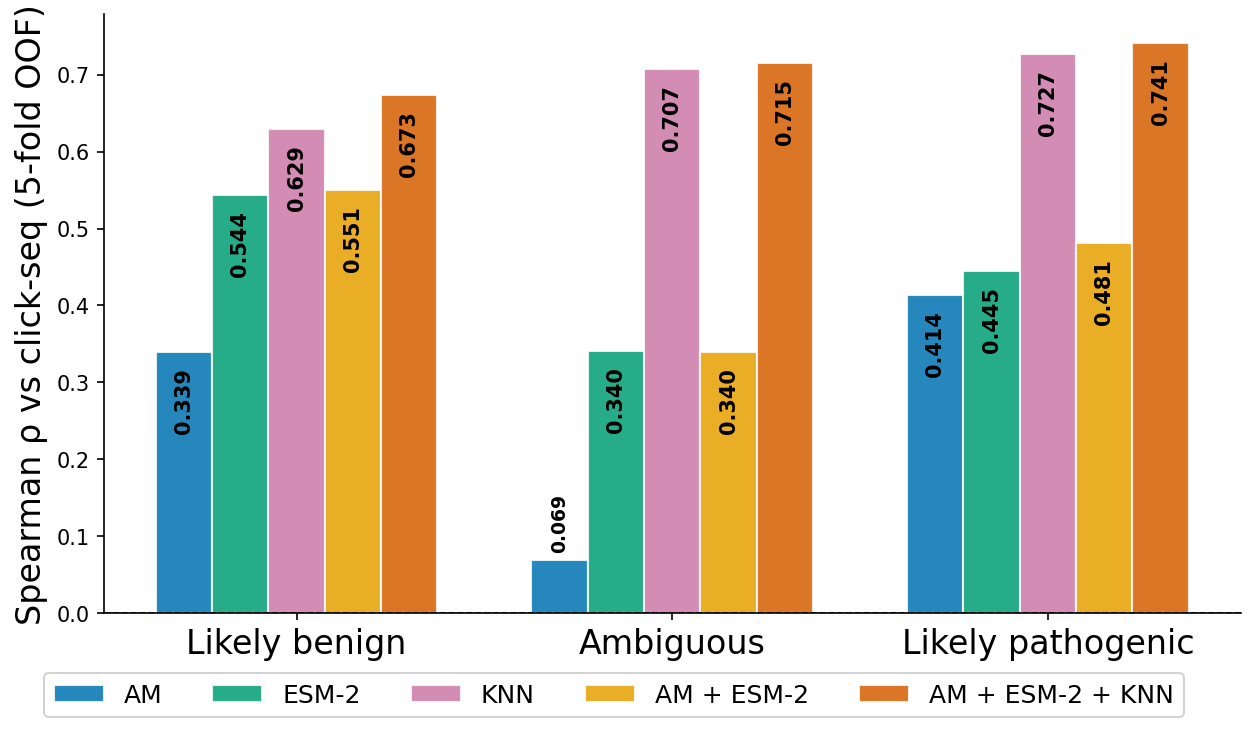

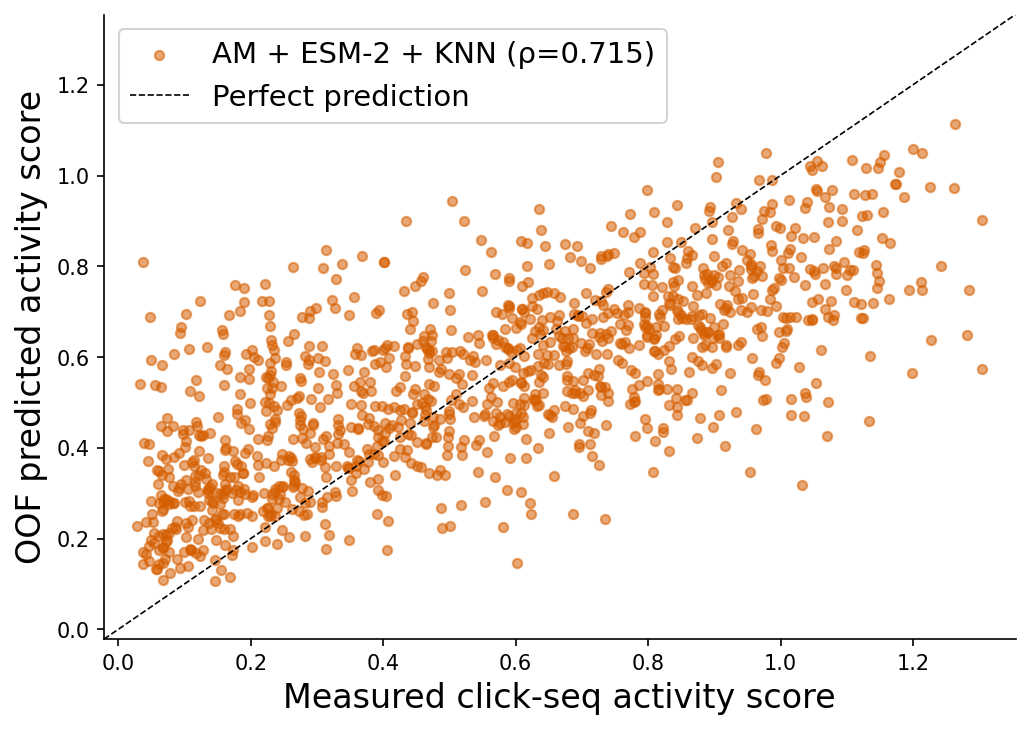

In [12]:
cap = lambda s: s[:1].upper() + s[1:]   # capitalize first letter only, leave the rest
fix_label = lambda s: s.replace('-only', '').replace('KNN-embed', 'KNN').replace('ESM2', 'ESM-2')

# ── Figure 1: per-class grouped bar chart for the embedding subset ───────────
fig1, ax = plt.subplots(figsize=(10, 5))
models_plot  = list(model_cols_emb.keys())
colors_plot  = ['#0072B2', '#009E73', '#CC79A7', '#E69F00', '#D55E00']
x     = np.arange(len(CLASS_ORDER))
width = 0.15

for i, (model, color) in enumerate(zip(models_plot, colors_plot)):
    col    = model_cols_emb[model]
    r_vals = [emb_class_results[cls][model][1] for cls in CLASS_ORDER]
    offset = (i - len(models_plot) / 2 + 0.5) * width
    bars   = ax.bar(x + offset, r_vals, width, label=cap(fix_label(model)), color=color,
                    alpha=0.85, edgecolor='white')

    for bar, v in zip(bars, r_vals):
        h = bar.get_height()
        if abs(h) >= 0.12:                      # tall enough → label inside
            ax.text(bar.get_x() + bar.get_width() / 2, h - 0.02,
                    f'{v:.3f}', ha='center', va='top', fontsize=10,
                    color='black', fontweight='bold', rotation=90)
        else:                                   # short bar → label just past the end
            va  = 'bottom' if h >= 0 else 'top'
            off = 0.01 if h >= 0 else -0.01
            ax.text(bar.get_x() + bar.get_width() / 2, h + off,
                    f'{v:.3f}', ha='center', va=va, fontsize=9,
                    color='black', fontweight='bold', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([cap(c.replace('_', ' ')) for c in CLASS_ORDER], fontsize=16)
ax.set_ylabel('Spearman ρ vs click-seq (5-fold OOF)', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=12, ncol=5, bbox_to_anchor=(0.95, -0.1), borderaxespad=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig1.tight_layout(rect=[0, 0, 0.85, 1])   # reserve right margin for the legend
plt.show()

# ── Figure 2: ambiguous variants scatter — AM + ESM-2 + KNN only ─────────────
fig2, ax = plt.subplots(figsize=(7, 5))
amb_emb = emb_train[emb_train['am_class'] == 'ambiguous'].dropna(subset=['click-seq_score'])
r_ens_knn, _ = stats.spearmanr(amb_emb['oof_ens_knn'], amb_emb['click-seq_score'])

h_ens_knn = ax.scatter(amb_emb['click-seq_score'], amb_emb['oof_ens_knn'],
                       alpha=0.55, s=20, color='#D55E00',
                       label=cap(f'AM + ESM-2 + KNN (ρ={r_ens_knn:.3f})'), rasterized=True)

lims = [amb_emb['click-seq_score'].min() - 0.05,
        amb_emb['click-seq_score'].max() + 0.05]
h_perfect, = ax.plot(lims, lims, 'k--', linewidth=0.8, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured click-seq activity score', fontsize=16)
ax.set_ylabel('OOF predicted activity score', fontsize=16)

ax.legend(handles=[h_ens_knn, h_perfect], fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig2.tight_layout()
plt.show()

## Statistical test: does Ensemble+KNN significantly outperform AM-only on ambiguous variants?

Because both predictions are made on the **same** variants, the two Spearman correlations are dependent. We use the **Steiger–Meng test** (Meng, Rosenthal & Rubin 1992) for comparing two correlated correlations:

- r₁₂ = Spearman(OOF AM-only predictions, actual activity)
- r₁₃ = Spearman(OOF Ensemble+KNN predictions, actual activity)
- r₂₃ = Spearman(AM-only predictions, Ensemble+KNN predictions)

H₁ (one-sided): r₁₂ < r₁₃ — Ensemble+KNN predictions correlate more strongly with actual activity than AM-only predictions.

Evaluated on the **embedding subset** (variants with ESM-2 representations available).

In [13]:
def steiger_meng_test(r12, r13, r23, n):
    """
    Compare two dependent correlations r12 and r13 (both on the same n observations).
    r23 = correlation between the two predictors.
    Returns z-statistic and one-sided p-value for H1: r12 < r13 (r13 is a stronger predictor).
    Meng, Rosenthal & Rubin (1992) Psychological Bulletin.
    """
    z12 = np.arctanh(r12)
    z13 = np.arctanh(r13)
    r_bar    = (r12 + r13) / 2
    r_bar_sq = r_bar ** 2
    f  = (1 - r23) / (2 * (1 - r_bar_sq))
    h  = (1 - f * r_bar_sq) / (1 - r_bar_sq)
    se = np.sqrt((2 * (1 - r23) * h) / (n - 3))
    z  = (z12 - z13) / se
    p_one_sided = stats.norm.cdf(z)     # H1: r12 < r13  (z < 0 when Ensemble+KNN is better)
    return z, p_one_sided

print('Steiger-Meng test: Ensemble+KNN vs AM-only, per AM class (embedding subset)')
print('H1 (one-sided): r(AM-only, actual) < r(Ensemble+KNN, actual)\n')
print(f'{"AM class":<24} {"r(AM-only)":>12} {"r(Ens+KNN)":>12} {"r(AM,Ens+KNN)":>14}  {"z":>8}  {"p (raw)":>10}  {"p (Bonf)":>10}')
print('-' * 98)

raw_pvals, rows = [], []
for cls in CLASS_ORDER:
    sub     = emb_train[emb_train['am_class'] == cls].dropna(subset=['click-seq_score'])
    y_sub   = sub['click-seq_score'].values
    p_am    = sub['oof_am_emb'].values
    p_ensk  = sub['oof_ens_knn'].values
    n       = len(sub)
    r12, _  = stats.spearmanr(y_sub, p_am)
    r13, _  = stats.spearmanr(y_sub, p_ensk)
    r23, _  = stats.spearmanr(p_am,  p_ensk)
    z, p    = steiger_meng_test(r12, r13, r23, n)
    raw_pvals.append(p)
    rows.append((cls, n, r12, r13, r23, z, p))

_, p_bonf, _, _ = multipletests(raw_pvals, method='bonferroni')
for (cls, n, r12, r13, r23, z, p), pb in zip(rows, p_bonf):
    print(f'  {cls:<22} {r12:>12.3f} {r13:>12.3f} {r23:>14.3f}  {z:>8.3f}  {p:>10.3e}  {pb:>10.3e}')

Steiger-Meng test: Ensemble+KNN vs AM-only, per AM class (embedding subset)
H1 (one-sided): r(AM-only, actual) < r(Ensemble+KNN, actual)

AM class                   r(AM-only)   r(Ens+KNN)  r(AM,Ens+KNN)         z     p (raw)    p (Bonf)
--------------------------------------------------------------------------------------------------
  likely_benign                 0.339        0.673          0.508   -21.162   1.078e-99   3.235e-99
  ambiguous                     0.069        0.715          0.163   -21.007   2.819e-98   8.456e-98
  likely_pathogenic             0.414        0.741          0.529   -22.653  6.511e-114  1.953e-113


## Ridge coefficient interpretation

In [14]:
# Fit final ensemble on all training data to inspect parameters
ensemble_pipe.fit(X_ens, y)

if hasattr(ensemble_pipe, 'weights_'):
    print(f'AM + ESM-2 ({_ens2_method}):')
    print(f'  am_activity   weight: {ensemble_pipe.weights_[0]:.4f}')
    print(f'  esm2_activity weight: {ensemble_pipe.weights_[1]:.4f}')
    _denom = max(ensemble_pipe.weights_[0], 1e-9)
    print(f'  Relative ESM-2 / AM: {ensemble_pipe.weights_[1] / _denom:.3f}x')
else:
    _r = ensemble_pipe.ridge_['ridge']
    print(f'AM + ESM-2 Ridge (alpha={_r.alpha_:.4f}):')
    print(f'  am_activity   coef: {_r.coef_[0]:+.4f}')
    print(f'  esm2_activity coef: {_r.coef_[1]:+.4f}')
    print(f'  Relative ESM-2 / AM: {abs(_r.coef_[1]) / abs(_r.coef_[0]):.3f}x')

# Per-class baseline Spearman r (feature vs click-seq)
print('\nPer-class baseline Spearman r (feature vs click-seq):')
print(f'{"AM class":<24} {"AM score":>10}  {"ESM-2 mmp":>12}  {"ESM-2/AM ratio":>15}')
print('-' * 66)
for cls in CLASS_ORDER:
    sub = train[train['am_class'] == cls].dropna(subset=['click-seq_score'])
    r_am,  _ = stats.spearmanr(sub['am_score'],  sub['click-seq_score'])
    r_esm, _ = stats.spearmanr(sub['esm2_mmp'],  sub['click-seq_score'])
    ratio = abs(r_esm) / abs(r_am) if r_am != 0 else float('inf')
    print(f'  {cls:<22} {r_am:>10.3f}  {r_esm:>12.3f}  {ratio:>15.3f}x')

# AM + ESM-2 + KNN ensemble parameters (fit on embedding subset)
ens_knn_inspect = BestEnsemblePlusKNN(k=5).fit(X_combined, y_emb)

if hasattr(ens_knn_inspect, 'weights_'):
    print(f'\nAM + ESM-2 + KNN ({_knn_method}):')
    print(f'  am_activity   weight: {ens_knn_inspect.weights_[0]:.4f}')
    print(f'  esm2_activity weight: {ens_knn_inspect.weights_[1]:.4f}')
    print(f'  knn_activity  weight: {ens_knn_inspect.weights_[2]:.4f}')
    _d = max(ens_knn_inspect.weights_[0], 1e-9)
    print(f'  Relative ESM-2 / AM:  {ens_knn_inspect.weights_[1] / _d:.3f}x')
    print(f'  Relative KNN  / AM:   {ens_knn_inspect.weights_[2] / _d:.3f}x')
else:
    _rk = ens_knn_inspect.ridge_['ridge']
    _ck = _rk.coef_
    print(f'\nAM + ESM-2 + KNN Ridge (alpha={_rk.alpha_:.4f}):')
    print(f'  am_activity   coef: {_ck[0]:+.4f}')
    print(f'  esm2_activity coef: {_ck[1]:+.4f}')
    print(f'  knn_activity  coef: {_ck[2]:+.4f}')
    print(f'  Relative ESM-2 / AM:  {abs(_ck[1]) / abs(_ck[0]):.3f}x')
    print(f'  Relative KNN  / AM:   {abs(_ck[2]) / abs(_ck[0]):.3f}x')


AM + ESM-2 Ridge (alpha=14.5635):
  am_activity   coef: +0.0995
  esm2_activity coef: +0.1658
  Relative ESM-2 / AM: 1.666x

Per-class baseline Spearman r (feature vs click-seq):
AM class                   AM score     ESM-2 mmp   ESM-2/AM ratio
------------------------------------------------------------------
  likely_benign              -0.354         0.545            1.539x
  ambiguous                  -0.130         0.342            2.640x
  likely_pathogenic          -0.423         0.446            1.055x

AM + ESM-2 + KNN Ridge (alpha=6.2506):
  am_activity   coef: +0.0414
  esm2_activity coef: +0.0636
  knn_activity  coef: +0.2216
  Relative ESM-2 / AM:  1.536x
  Relative KNN  / AM:   5.352x


## Summary

In [15]:
amb_am  = class_results['ambiguous']['AM-only'][1]
amb_ens = class_results['ambiguous']['AM + ESM-2'][1]
ben_am  = class_results['likely_benign']['AM-only'][1]
pat_am  = class_results['likely_pathogenic']['AM-only'][1]

print('=== Summary ===')
print(f'\n--- Full dataset (n = {len(train):,}) ---')
print(f'AM-only   ambiguous Spearman r  : {amb_am:.3f}')
print(f'Ensemble  ambiguous Spearman r  : {amb_ens:.3f}  (delta = {amb_ens - amb_am:+.3f})')
print(f'\nAM-only  benign    Spearman r  : {ben_am:.3f}')
print(f'AM-only  pathogenic Spearman r : {pat_am:.3f}')
print(f'\nGap to close (ambiguous vs average of benign/pathogenic):')
target = (ben_am + pat_am) / 2
gap_before = abs(amb_am  - target)
gap_after  = abs(amb_ens - target)
print(f'  Before ensemble: {gap_before:.3f}')
print(f'  After  ensemble: {gap_after:.3f}  ({(1 - gap_after/gap_before)*100:.3f}% of gap closed)')

print(f'\n--- Embedding subset (n = {len(emb_train)}) ---')
emb_amb_am      = emb_class_results['ambiguous']['AM-only'][1]
emb_amb_knn     = emb_class_results['ambiguous']['KNN-embed'][1]
emb_amb_ens     = emb_class_results['ambiguous']['AM + ESM-2'][1]
emb_amb_ens_knn = emb_class_results['ambiguous']['AM + ESM-2 + KNN'][1]
print(f'AM-only      ambiguous Spearman r : {emb_amb_am:.3f}')
print(f'KNN-embed    ambiguous Spearman r : {emb_amb_knn:.3f}  (delta vs AM = {emb_amb_knn - emb_amb_am:+.3f})')
print(f'Ensemble     ambiguous Spearman r : {emb_amb_ens:.3f}  (delta vs AM = {emb_amb_ens - emb_amb_am:+.3f})')
print(f'Ensemble+KNN ambiguous Spearman r : {emb_amb_ens_knn:.3f}  (delta vs AM = {emb_amb_ens_knn - emb_amb_am:+.3f})')

=== Summary ===

--- Full dataset (n = 6,145) ---
AM-only   ambiguous Spearman r  : 0.069
Ensemble  ambiguous Spearman r  : 0.340  (delta = +0.271)

AM-only  benign    Spearman r  : 0.339
AM-only  pathogenic Spearman r : 0.414

Gap to close (ambiguous vs average of benign/pathogenic):
  Before ensemble: 0.308
  After  ensemble: 0.037  (88.060% of gap closed)

--- Embedding subset (n = 6145) ---
AM-only      ambiguous Spearman r : 0.069
KNN-embed    ambiguous Spearman r : 0.707  (delta vs AM = +0.638)
Ensemble     ambiguous Spearman r : 0.340  (delta vs AM = +0.271)
Ensemble+KNN ambiguous Spearman r : 0.715  (delta vs AM = +0.646)


## ClinVar Variant Activity Prediction

In [16]:
AA1_TO_3 = {
    'A':'Ala','C':'Cys','D':'Asp','E':'Glu','F':'Phe','G':'Gly',
    'H':'His','I':'Ile','K':'Lys','L':'Leu','M':'Met','N':'Asn',
    'P':'Pro','Q':'Gln','R':'Arg','S':'Ser','T':'Thr','V':'Val',
    'W':'Trp','Y':'Tyr'
}

def mut_1to3(s):
    p = parse_mut(s)
    if p is None: return None
    ref, pos, alt = p
    r3, a3 = AA1_TO_3.get(ref), AA1_TO_3.get(alt)
    return f'{r3}{pos}{a3}' if r3 and a3 else None

def assign_category(fe):
    fe_l = str(fe).lower()
    if 'likely pathogenic' in fe_l: return 'likely_pathogenic'
    if 'pathogenic'        in fe_l: return 'pathogenic'
    if 'likely benign'     in fe_l: return 'likely_benign'
    if 'benign'            in fe_l: return 'benign'
    if 'uncertain'         in fe_l: return 'uncertain_significance'
    return 'other'

# ── Exclude ClinVar variants from training, then fit all five models ─────────────────────
_clinvar_midx = pd.MultiIndex.from_tuples(clinvar_rpa)
_in_cv        = pd.MultiIndex.from_arrays([merged['ref'], merged['pos'], merged['alt']]).isin(_clinvar_midx)
_fit_cv       = merged[~_in_cv][['mutation', 'ref', 'pos', 'alt',
                                  'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
train_cv      = _fit_cv.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
print(f'ClinVar exclusion: removed {_in_cv.sum()} variants from merged; {len(train_cv):,} remain for training\n')

y_cv      = train_cv['click-seq_score'].values
X_am_cv   = train_cv['am_score'].values
X_esm_cv  = train_cv['esm2_mmp'].values
X_ens_cv  = train_cv[['am_score', 'esm2_mmp']].values

am_iso_final   = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am_cv,  y_cv)
esm2_sig_final = MonotoneSigmoid().fit(X_esm_cv, y_cv)
ens_pipe_cv    = BestEnsemble2().fit(X_ens_cv, y_cv)

# KNN: slice pre-computed emb_train/X_emb to drop ClinVar rows (no disk re-load)
_in_cv_emb   = pd.MultiIndex.from_arrays(
    [emb_train['ref'], emb_train['pos'], emb_train['alt']]).isin(_clinvar_midx)
_mask_cv_emb = ~_in_cv_emb
emb_train_cv = emb_train[_mask_cv_emb].copy().reset_index(drop=True)
X_emb_cv     = X_emb[_mask_cv_emb]
y_emb_cv     = emb_train_cv['click-seq_score'].values

knn_final     = Pipeline([('scaler', StandardScaler()),
                           ('knn',   KNeighborsRegressor(n_neighbors=5,
                                                          weights='distance', metric='cosine'))
                          ]).fit(X_emb_cv, y_emb_cv)
ens_knn_final = BestEnsemblePlusKNN(k=5).fit(
    np.column_stack([emb_train_cv[['am_score', 'esm2_mmp']].values, X_emb_cv]), y_emb_cv)

# ── Build prediction dataframe ────────────────────────────────────────────
cv_pred = result.copy()
cv_pred['mutation_3l'] = cv_pred['mutation'].apply(mut_1to3)
_parsed = cv_pred['mutation'].apply(parse_mut)
cv_pred['ref'] = _parsed.apply(lambda x: x[0] if x else None)
cv_pred['pos'] = pd.to_numeric(_parsed.apply(lambda x: x[1] if x else None), errors='coerce')
cv_pred['alt'] = _parsed.apply(lambda x: x[2] if x else None)
cv_pred['category'] = cv_pred['functional_effect'].apply(assign_category)

# AM scores
cv_pred = cv_pred.merge(
    am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='left'
)
# ESM-2 masked marginal
cv_pred = cv_pred.merge(
    esm2.rename(columns={'mutation': 'mutation_3l'}), on='mutation_3l', how='left'
)
# Click-seq ground truth (held-out)
_click = (merged[['ref', 'pos', 'alt', 'click-seq_score']]
          .dropna(subset=['click-seq_score'])
          .drop_duplicates(['ref', 'pos', 'alt']))
cv_pred = cv_pred.merge(_click, on=['ref', 'pos', 'alt'], how='left')

print(f'ClinVar variants: {len(cv_pred)} rows ({cv_pred["mutation"].nunique()} unique mutations)')
print(f'  AM score:  {cv_pred["am_score"].notna().sum()}  '
      f'ESM-2 MMP: {cv_pred["esm2_mmp"].notna().sum()}  '
      f'Click-seq: {cv_pred["click-seq_score"].notna().sum()} (held-out)\n')

# ── AM individually (isotonic, decreasing) ─────────────────────────────────────────
has_am   = cv_pred['am_score'].notna()
has_esm2 = cv_pred['esm2_mmp'].notna()
has_ens  = has_am & has_esm2

cv_pred['pred_am'] = np.nan
cv_pred.loc[has_am, 'pred_am'] = am_iso_final.predict(cv_pred.loc[has_am, 'am_score'].values)

# ── ESM-2 individually (isotonic, increasing) ─────────────────────────────────────────
cv_pred['pred_esm2'] = np.nan
cv_pred.loc[has_esm2, 'pred_esm2'] = esm2_sig_final.predict(cv_pred.loc[has_esm2, 'esm2_mmp'].values)

# ── Ensemble (AM + ESM-2) ─────────────────────────────────────────────────────────
cv_pred['pred_ensemble'] = np.nan
cv_pred.loc[has_ens, 'pred_ensemble'] = ens_pipe_cv.predict(
    cv_pred.loc[has_ens, ['am_score', 'esm2_mmp']].values
)

# ── Embedding availability ─────────────────────────────────────────────────────────────────────────
cv_pred['has_embedding'] = cv_pred['mutation_3l'].isin(mut_to_idx)
has_knn = has_ens & cv_pred['has_embedding']

if has_knn.sum() > 0:
    _rows    = [mut_to_idx[m] for m in cv_pred.loc[has_knn, 'mutation_3l']]
    X_cv_emb = rep_matrix[_rows].mean(axis=1).astype(np.float32)
else:
    X_cv_emb = None

# ── KNN individually ───────────────────────────────────────────────────────────────────────────────────────────────────────
cv_pred['pred_knn'] = np.nan
if X_cv_emb is not None:
    cv_pred.loc[has_knn, 'pred_knn'] = knn_final.predict(X_cv_emb)

# ── Ensemble + KNN ─────────────────────────────────────────────────────────────────────────────────────────────────────
cv_pred['pred_ens_knn'] = np.nan
if X_cv_emb is not None:
    X_cv_comb = np.column_stack([cv_pred.loc[has_knn, ['am_score', 'esm2_mmp']].values, X_cv_emb])
    cv_pred.loc[has_knn, 'pred_ens_knn'] = ens_knn_final.predict(X_cv_comb)

print('Predictions complete:')
print(f'  AM (individual):     {cv_pred["pred_am"].notna().sum()}')
print(f'  ESM-2 (individual):  {cv_pred["pred_esm2"].notna().sum()}')
print(f'  Ensemble (AM+ESM-2): {cv_pred["pred_ensemble"].notna().sum()}')
print(f'  KNN (individual):    {cv_pred["pred_knn"].notna().sum()}')
print(f'  Ensemble+KNN:        {cv_pred["pred_ens_knn"].notna().sum()}')
cv_pred[['mutation', 'category', 'am_score', 'am_class', 'esm2_mmp',
         'pred_am', 'pred_esm2', 'pred_ensemble', 'pred_knn', 'pred_ens_knn', 'click-seq_score']]


ClinVar exclusion: removed 38 variants from merged; 6,121 remain for training

ClinVar variants: 50 rows (48 unique mutations)
  AM score:  49  ESM-2 MMP: 45  Click-seq: 30 (held-out)

Predictions complete:
  AM (individual):     49
  ESM-2 (individual):  45
  Ensemble (AM+ESM-2): 45
  KNN (individual):    45
  Ensemble+KNN:        45


,mutation,category,am_score,am_class,esm2_mmp,pred_am,pred_esm2,pred_ensemble,pred_knn,pred_ens_knn,click-seq_score
0,V6F,uncertain_significance,0.0774,likely_benign,-0.667392,0.974255,0.877352,0.952735,0.987796,1.020998,NaN
1,L9F,uncertain_significance,0.0829,likely_benign,-1.519629,0.951332,0.819778,0.904241,1.006946,1.015935,0.901104
2,C10Y,uncertain_significance,0.2530,likely_benign,-4.357482,0.684143,0.587343,0.633512,0.638204,0.638659,0.544437
3,L15I,uncertain_significance,0.0966,likely_benign,-2.411788,0.914778,0.752045,0.843077,0.984496,0.975350,NaN
4,P35S,uncertain_significance,0.2714,likely_benign,-4.158930,0.645612,0.604631,0.628582,0.388380,0.453382,NaN
5,I42N,uncertain_significance,0.3877,ambiguous,NaN,0.597776,NaN,NaN,NaN,NaN,NaN
6,G46V,uncertain_significance,0.2963,likely_benign,-3.857610,0.645612,0.630816,0.646163,0.420766,0.484088,0.316458
7,Y80F,uncertain_significance,0.1306,likely_benign,NaN,0.830212,NaN,NaN,NaN,NaN,NaN
8,K84E,uncertain_significance,0.3160,likely_benign,-7.521041,0.619328,0.335246,0.436435,0.662287,0.578624,0.519647
9,D89G,uncertain_significance,0.1642,likely_benign,-4.660036,0.788862,0.561040,0.660794,0.712555,0.703925,NaN


In [17]:
# Ensemble model parameters (ClinVar-excluded final fit)
# Inputs are calibrated activity predictions (standardised for Ridge).

def _print_model_params(model, label):
    if hasattr(model, 'weights_'):
        names = (['am_activity', 'esm2_activity'] if len(model.weights_) == 2
                 else ['am_activity', 'esm2_activity', 'knn_activity'])
        print(f'{label} (Constrained):')
        for nm, w in zip(names, model.weights_):
            print(f'  {nm:<14} weight: {w:.4f}')
    else:
        r = model.ridge_['ridge']
        names = (['am_activity', 'esm2_activity'] if len(r.coef_) == 2
                 else ['am_activity', 'esm2_activity', 'knn_activity'])
        print(f'{label} Ridge (alpha={r.alpha_:.3g}):')
        for nm, c in zip(names, r.coef_):
            print(f'  {nm:<14} coef: {c:+.4f}')
        print(f'  {"intercept":<14} {r.intercept_:+.4f}')

_print_model_params(ens_pipe_cv,   'AM + ESM-2')
print()
_print_model_params(ens_knn_final, 'AM + ESM-2 + KNN')


AM + ESM-2 Ridge (alpha=14.6):
  am_activity    coef: +0.1008
  esm2_activity  coef: +0.1647
  intercept      +0.5403

AM + ESM-2 + KNN Ridge (alpha=6.25):
  am_activity    coef: +0.0396
  esm2_activity  coef: +0.0650
  knn_activity   coef: +0.2217
  intercept      +0.5403


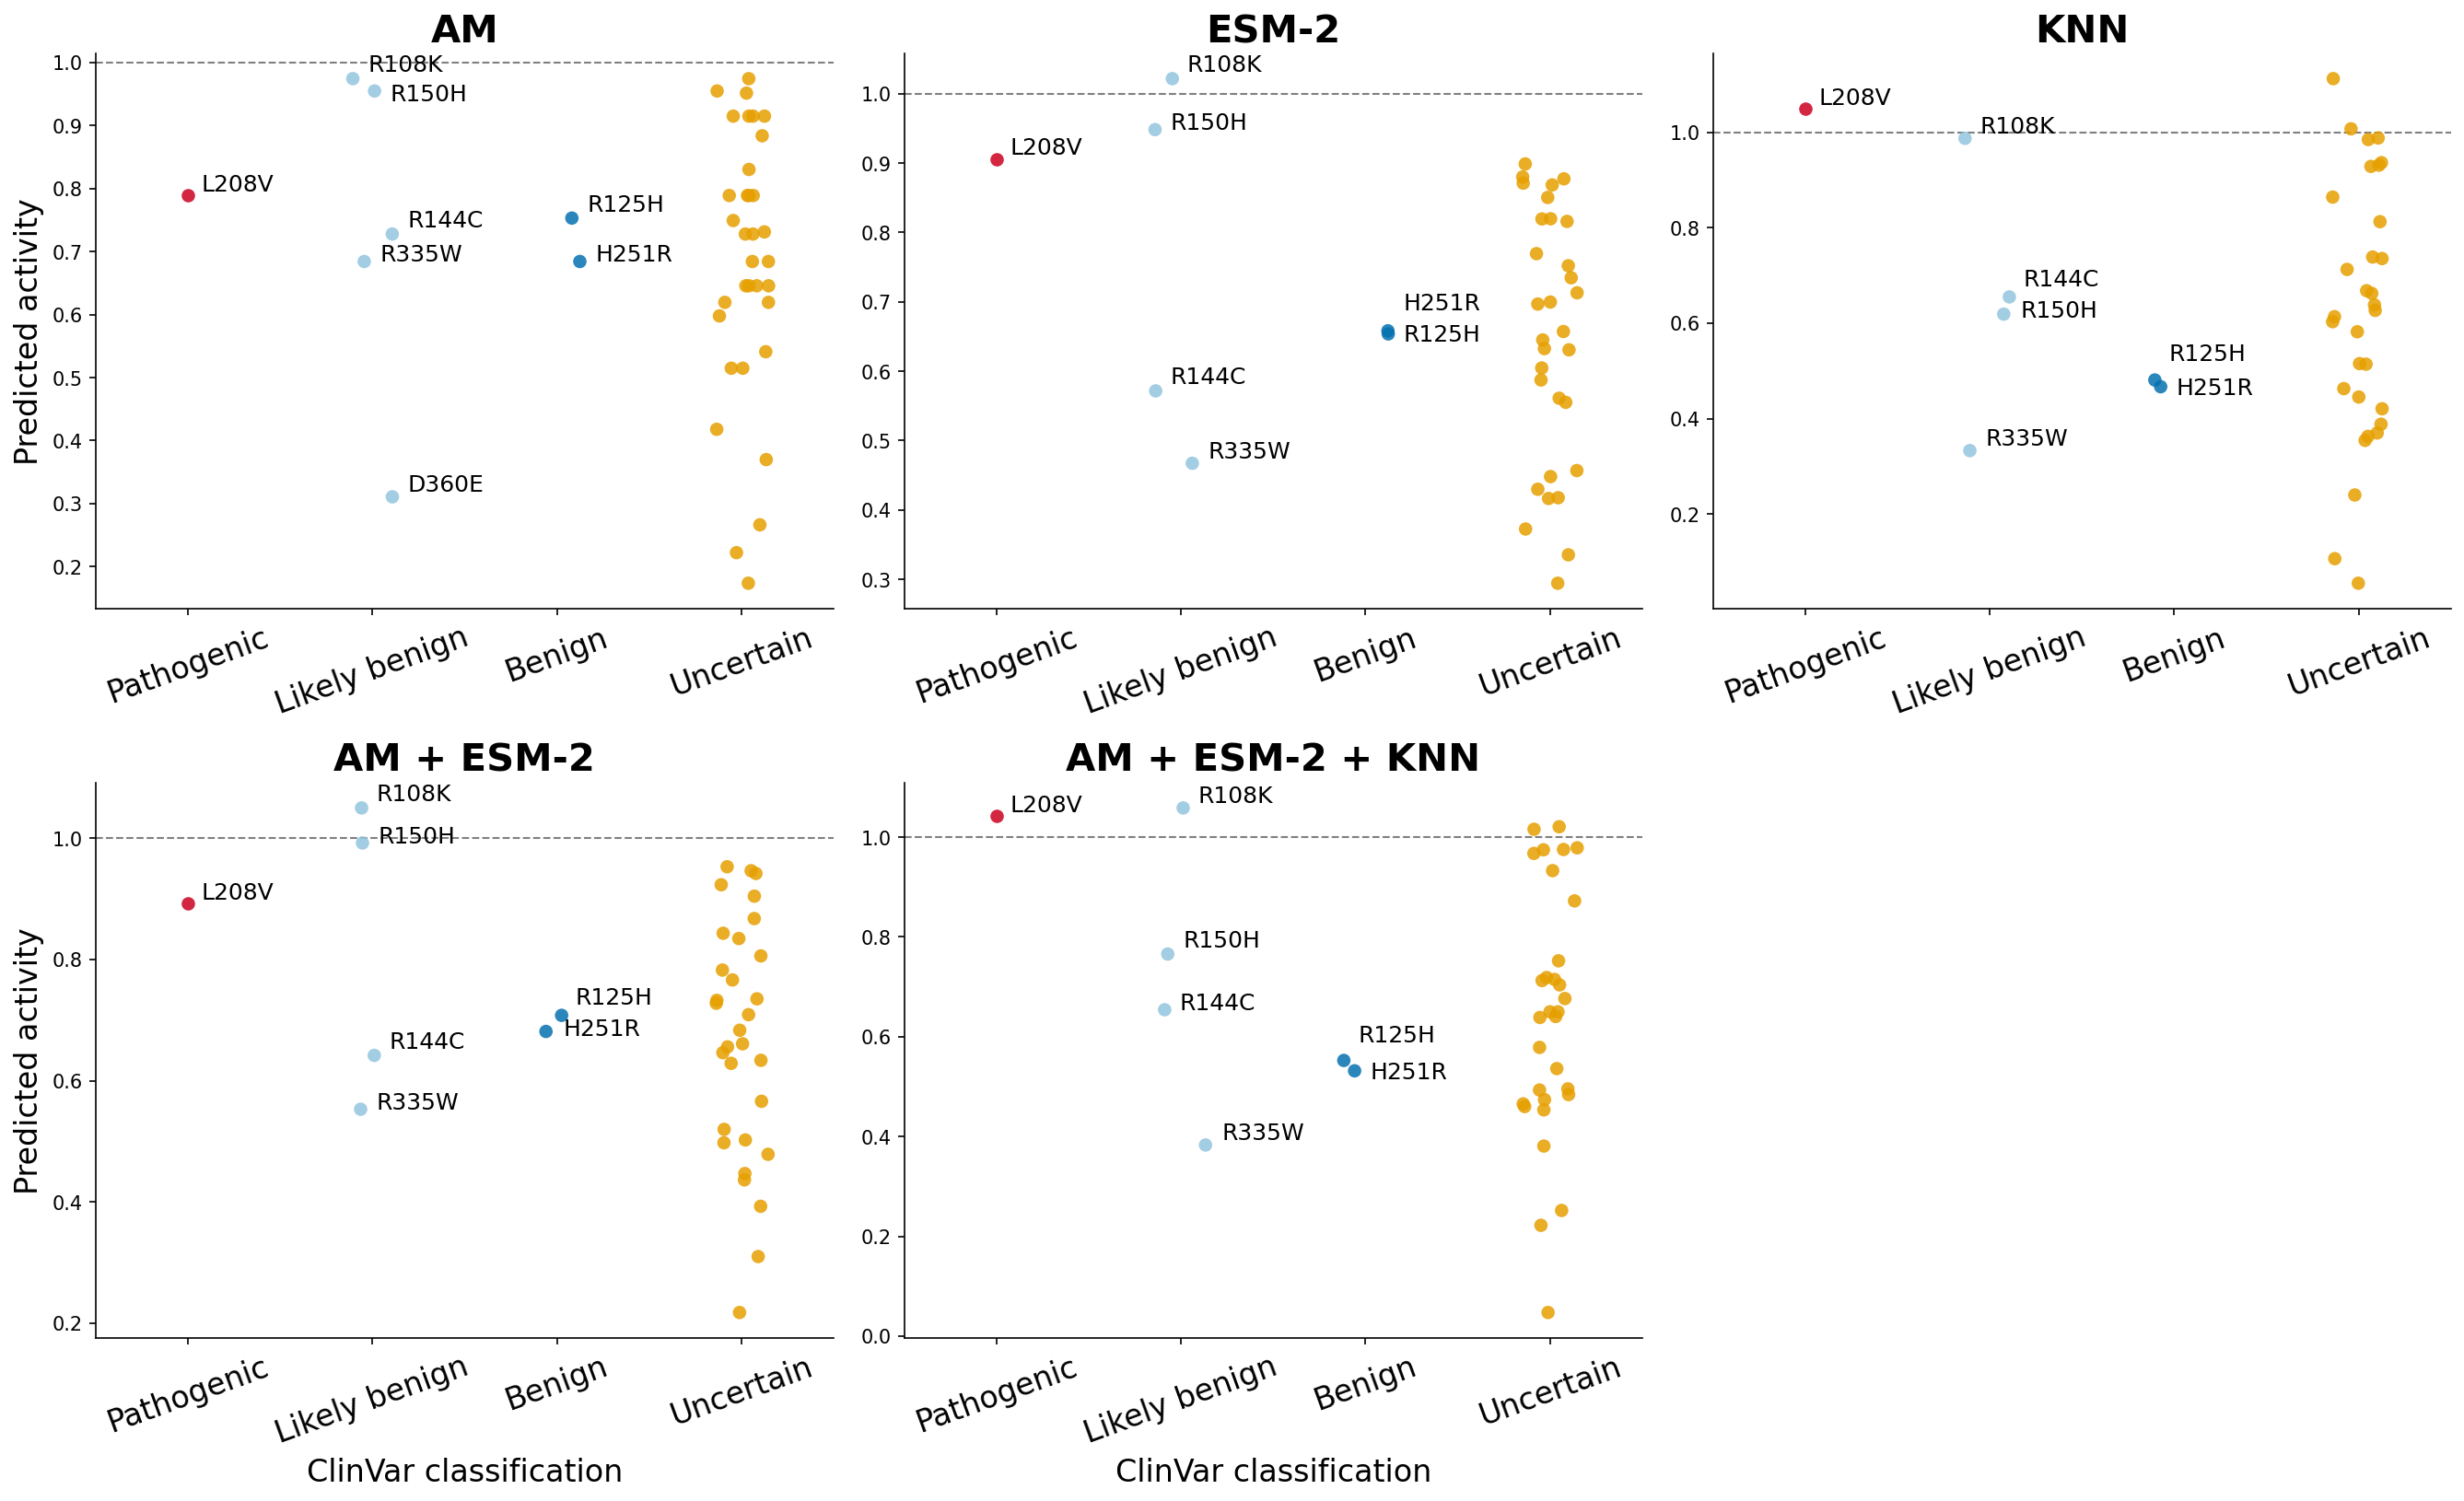

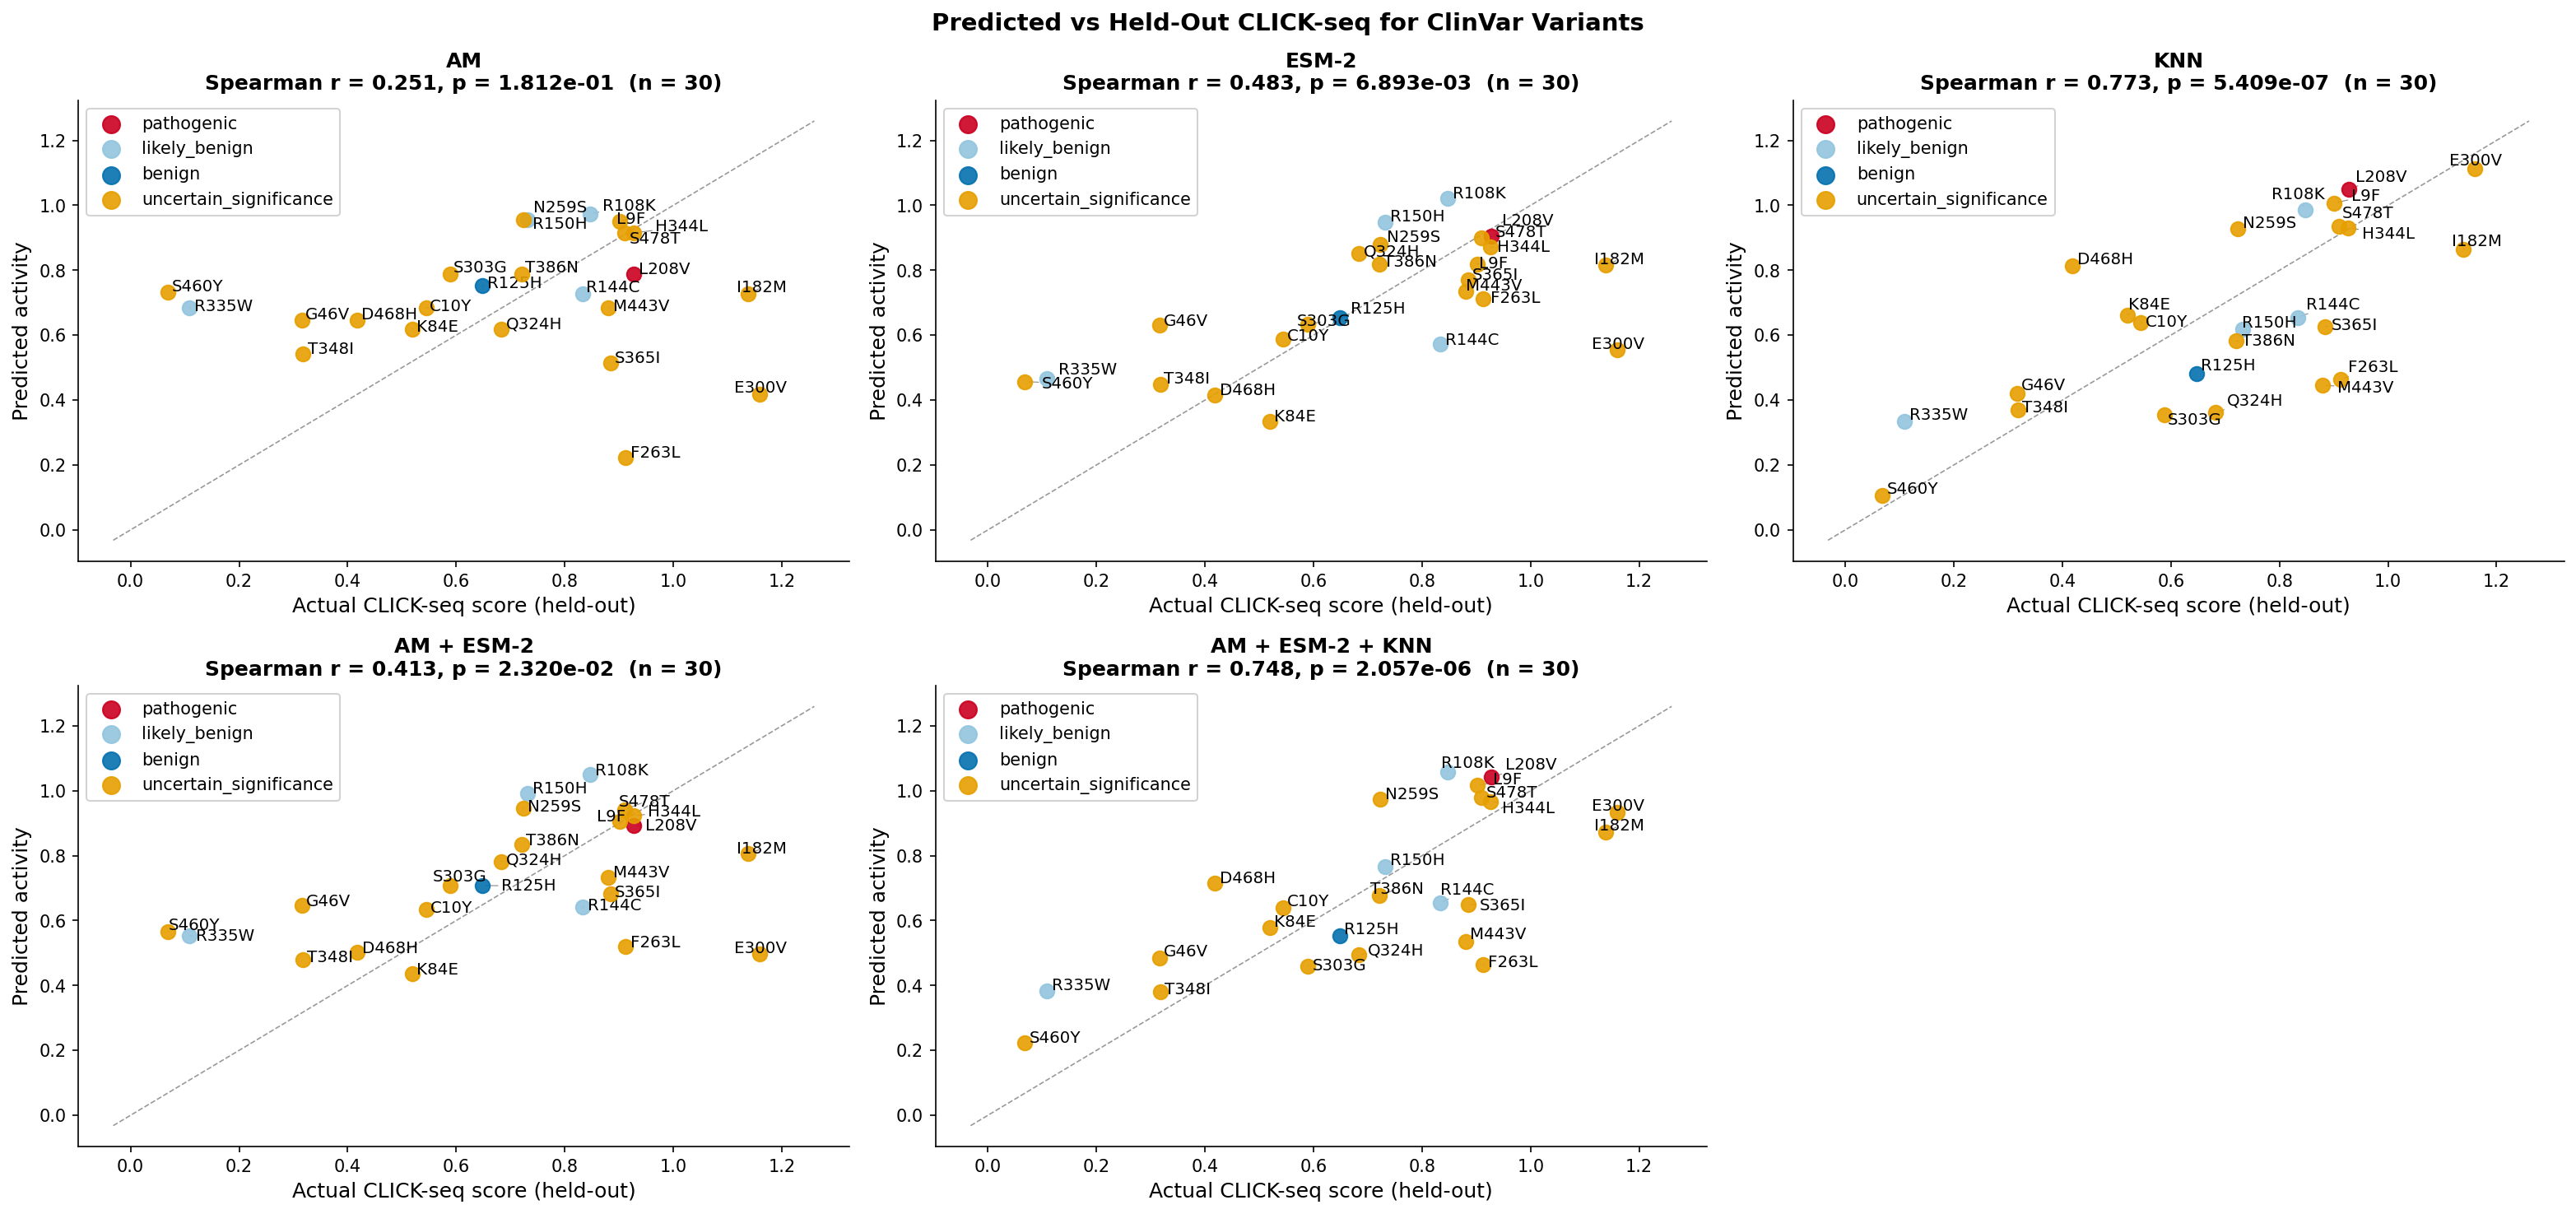

In [18]:
CAT_ORDER  = ['pathogenic', 'likely_benign', 'benign', 'uncertain_significance']
CAT_COLORS = {
    'benign':                 '#0571B0',
    'likely_benign':           '#92C5DE',
    'uncertain_significance':  '#E69F00',
    'likely_pathogenic':       '#F4A582',
    'pathogenic':              '#CA0020',
}
MODELS = [
    ('pred_am',       'AM'),
    ('pred_esm2',     'ESM-2'),
    ('pred_knn',      'KNN'),
    ('pred_ensemble', 'AM + ESM-2'),
    ('pred_ens_knn',  'AM + ESM-2 + KNN'),
]

# Ordinal severity scale for quantifying predicted-activity vs. ClinVar-category
# correlation. Ascending = decreasing pathogenicity (matches the sign convention used
# for PharmVar's func_numeric, where higher = more functional/benign).
# uncertain_significance (VUS) is excluded -- like PharmVar's Uncertain/Unknown Function,
# it is a "we don't know" placeholder rather than a genuine ordinal middle position.
CAT_NUMERIC = {'pathogenic': 0, 'likely_pathogenic': 1, 'likely_benign': 2, 'benign': 3}
cv_pred['cat_numeric'] = cv_pred['category'].map(CAT_NUMERIC)


def plot_activity_by_category(ax, sub, pred_col, cats_sub, label_fontsize=12):
    """Strip plot of predicted activity vs. ClinVar category, with mutation labels
    on every category except uncertain_significance (too numerous to label)."""
    sns.stripplot(data=sub, x='category', y=pred_col, order=cats_sub,
                  hue='category', hue_order=cats_sub, palette=CAT_COLORS,
                  legend=False, ax=ax, jitter=0.15, size=7, alpha=0.85)

    label_cats = set(cats_sub) - {'uncertain_significance'}
    texts = []
    for coll, cat in zip(ax.collections, cats_sub):
        if cat not in label_cats:
            continue
        grp = sub[sub['category'] == cat]
        for (xj, yj) in coll.get_offsets():           # true jittered dot position
            idx = (grp[pred_col] - yj).abs().idxmin()  # match dot back to its mutation
            texts.append(ax.text(xj, yj, grp.loc[idx, 'mutation'], fontsize=label_fontsize))
    adjust_text(texts, ax=ax, only_move={'text': 'y'}, expand_text=(1.05, 1.2))

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='WT = 1.0')
    ax.set_xticks(range(len(cats_sub)))
    label_map = {'uncertain_significance': 'Uncertain'}
    ax.set_xticklabels([label_map.get(c, c.replace('_', ' ').capitalize()) for c in cats_sub],
                        fontsize=16)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── 1. Predicted activity by ClinVar category ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
ncols, n_used = 3, len(MODELS)

for ax_i, (pred_col, title) in enumerate(MODELS):
    ax = axes_flat[ax_i]
    sub = cv_pred[cv_pred[pred_col].notna()].copy()
    cats_sub = [c for c in CAT_ORDER if c in sub['category'].values]
    sub = sub[sub['category'].isin(cats_sub)].copy()   # drop 'other' / unlisted categories
    if sub.empty:
        ax.text(0.5, 0.5, 'No predictions', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue

    plot_activity_by_category(ax, sub, pred_col, cats_sub)

    ax.set_xlabel('ClinVar classification' if ax_i + ncols > n_used else '', fontsize=16)
    ax.set_ylabel('Predicted activity' if ax_i % ncols == 0 else '', fontsize=16)
    ax.set_title(title, fontsize=20, fontweight='bold')

axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

# ── 2. Predicted vs actual click-seq (held-out validation) ────────────────────
cv_click = cv_pred[cv_pred['click-seq_score'].notna()].copy()

if len(cv_click) >= 2:
    valid_models = [(col, title) for col, title in MODELS if cv_click[col].notna().any()]
    n_panels = len(valid_models)
    ncols = min(3, n_panels)
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_i, (pred_col, title) in enumerate(valid_models):
        ax = axes_flat[ax_i]
        sub = cv_click[cv_click[pred_col].notna()]
        if sub.empty:
            continue

        texts = []
        for cat in CAT_ORDER:
            grp = sub[sub['category'] == cat]
            if len(grp):
                ax.scatter(grp['click-seq_score'], grp[pred_col],
                           color=CAT_COLORS[cat], s=70, alpha=0.9, label=cat, zorder=3)
                for _, row in grp.iterrows():
                    texts.append(ax.text(row['click-seq_score'], row[pred_col],
                                         row['mutation'], fontsize=9.5))
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

        lo = min(sub['click-seq_score'].min(), sub[pred_col].min()) - 0.1
        hi = max(sub['click-seq_score'].max(), sub[pred_col].max()) + 0.1
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4)

        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['click-seq_score'], sub[pred_col])
            ax.set_title(f'{title}\nSpearman r = {r:.3f}, p = {p:.3e}  (n = {len(sub)})',
                         fontsize=12, fontweight='bold')
        else:
            ax.set_title(f'{title}  (n = {len(sub)})', fontsize=12, fontweight='bold')

        ax.set_xlabel('Actual CLICK-seq score (held-out)', fontsize=12)
        ax.set_ylabel('Predicted activity', fontsize=12)
        ax.legend(fontsize=10, markerscale=1.2)

    for ax_i in range(len(valid_models), nrows * ncols):
        axes_flat[ax_i].set_visible(False)

    fig.suptitle('Predicted vs Held-Out CLICK-seq for ClinVar Variants',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Only {len(cv_click)} ClinVar variant(s) with click-seq scores — skipping scatter.')


### Quantifying predicted activity vs. ClinVar category (all models)

Spearman ρ: predicted activity vs ordinal ClinVar category
(pathogenic=0, likely_pathogenic=1, likely_benign=2, benign=3;
 uncertain_significance/VUS excluded -- not a genuine ordinal middle, "unknown"
 the same way PharmVar's Uncertain/Unknown Function categories are)

  AM                  : rho=-0.270  p=0.518 ns  n=8
  ESM-2               : rho=-0.219  p=0.637 ns  n=7
  KNN                 : rho=-0.657  p=0.109 ns  n=7
  AM + ESM-2          : rho=-0.219  p=0.637 ns  n=7
  AM + ESM-2 + KNN    : rho=-0.558  p=0.193 ns  n=7


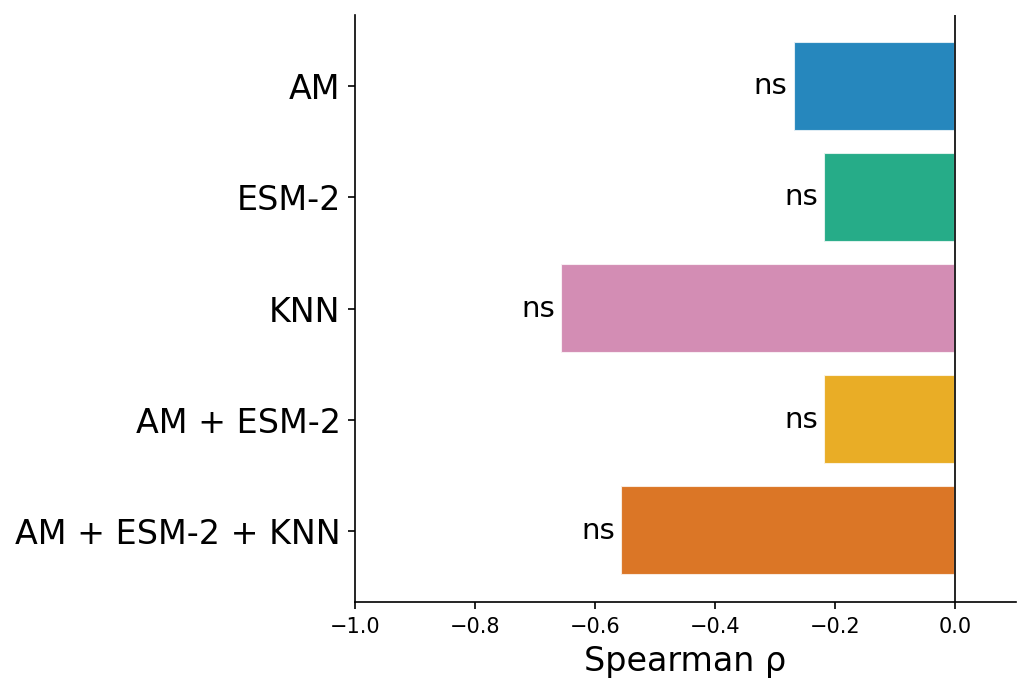

In [19]:
print('Spearman ρ: predicted activity vs ordinal ClinVar category')
print('(pathogenic=0, likely_pathogenic=1, likely_benign=2, benign=3;')
print(' uncertain_significance/VUS excluded -- not a genuine ordinal middle, "unknown"')
print(' the same way PharmVar\'s Uncertain/Unknown Function categories are)\n')

clinvar_ord_results = []
for pred_col, name in MODELS:
    sub = cv_pred.dropna(subset=['cat_numeric', pred_col])
    if len(sub) >= 3:
        rho, p = stats.spearmanr(sub['cat_numeric'], sub[pred_col])
    else:
        rho, p = float('nan'), float('nan')
    clinvar_ord_results.append(dict(model=name, rho=rho, p=p, n=len(sub)))
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {name:<20}: rho={rho:+.3f}  p={p:.3f} {stars}  n={len(sub)}')

# ── Bar chart: Spearman rho by model ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
names = [r['model'].replace('(individual)', '').strip() for r in clinvar_ord_results]
rhos  = [r['rho'] for r in clinvar_ord_results]
ps    = [r['p']   for r in clinvar_ord_results]

MODEL_COLORS = ['#0072B2', '#009E73', '#CC79A7', '#E69F00', '#D55E00']  # AM, ESM-2, KNN, AM+ESM-2, AM+ESM-2+KNN

ys   = range(len(names))
bars = ax.barh(list(ys), rhos, color=MODEL_COLORS[:len(names)], alpha=0.85, edgecolor='white')
for bar, v, p in zip(bars, rhos, ps):
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    yc = bar.get_y() + bar.get_height() / 2
    if v >= 0:
        ax.text(v + 0.01, yc, f'{stars}', va='center', ha='left', fontsize=14)
    else:
        ax.text(v - 0.01, yc, f'{stars}', va='center', ha='right', fontsize=14)

ax.set_yticks(list(ys))
ax.set_yticklabels(names, fontsize=16)
ax.invert_yaxis()                     # AM at top → AM + ESM-2 + KNN at bottom
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 0.1)                 # bars are all negative → trim empty right side
ax.set_xlabel('Spearman ρ', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## PharmVar Allele Activity Prediction

Predicts CYP2C9 functional activity for all 78 PharmVar missense alleles using all five methods.

**Function label encoding** for ordinal correlation (Uncertain / Unknown / Function Not Assigned are excluded from label correlations):

| PharmVar label | Ordinal score |
|---|---|
| No Function | 0 |
| Decreased Function | 1 |
| Normal Function | 2 |

**Evidence Level** (`Limited` / `Moderate` / `Definitive`) is incorporated by stratifying correlations at three inclusion thresholds and by encoding marker shape in visualisations.

In [20]:
PV_MODELS = [
    ('pred_am',       'AM (individual)'),
    ('pred_esm2',     'ESM-2 (individual)'),
    ('pred_ensemble', 'AM + ESM-2'),
    ('pred_knn',      'KNN (individual)'),
    ('pred_ens_knn',  'AM + ESM-2 + KNN'),
]

# ── Load PharmVar missense alleles ─────────────────────────────────────────────────────────────────────
pv = pd.read_csv(f'{DATA_DIR}/pharmvar_cyp2c9_missense_mutations_single.csv')
pv_rpa = set(zip(pv['ref'], pv['pos'].astype(int), pv['alt']))   # exclusion set before any merges

pv['mutation_3l'] = pv.apply(
    lambda r: f"{AA1_TO_3.get(r['ref'], '')}{r['pos']}{AA1_TO_3.get(r['alt'], '')}"
              if AA1_TO_3.get(r['ref']) and AA1_TO_3.get(r['alt']) else None,
    axis=1
)

# Merge AM scores, ESM-2 MMP, click-seq ground truth
pv = pv.merge(am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='left')
pv = pv.merge(esm2.rename(columns={'mutation': 'mutation_3l'}), on='mutation_3l', how='left')
_click_pv = (merged[['ref', 'pos', 'alt', 'click-seq_score']]
             .dropna(subset=['click-seq_score'])
             .drop_duplicates(['ref', 'pos', 'alt']))
pv = pv.merge(_click_pv, on=['ref', 'pos', 'alt'], how='left')

print(f'PharmVar alleles: {len(pv)}')
print(f'  AM score:  {pv["am_score"].notna().sum()}  '
      f'ESM-2 MMP: {pv["esm2_mmp"].notna().sum()}  '
      f'Click-seq: {pv["click-seq_score"].notna().sum()}\n')
print('Function breakdown:')
func_order_display = ['No Function', 'Decreased Function', 'Normal Function',
                      'Uncertain Function', 'Unknown Function', 'Function Not Assigned']
print(pv['Function'].value_counts().reindex(func_order_display).dropna().to_string())
print('\nEvidence Level breakdown:')
print(pv['Evidence Level'].value_counts().to_string())

# ── Exclude PharmVar variants from training (full merged as base, not ClinVar-excluded) ────
_pv_midx = pd.MultiIndex.from_tuples(pv_rpa)
_in_pv   = pd.MultiIndex.from_arrays([merged['ref'], merged['pos'], merged['alt']]).isin(_pv_midx)
_fit_pv  = merged[~_in_pv][['mutation', 'ref', 'pos', 'alt',
                              'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
train_pv = _fit_pv.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
print(f'\nPharmVar exclusion: removed {_in_pv.sum()} variants from merged; {len(train_pv):,} remain for training\n')

y_pv     = train_pv['click-seq_score'].values
X_am_pv  = train_pv['am_score'].values
X_esm_pv = train_pv['esm2_mmp'].values
X_ens_pv = train_pv[['am_score', 'esm2_mmp']].values

am_iso_pv   = IsotonicRegression(increasing=False, out_of_bounds='clip').fit(X_am_pv,  y_pv)
esm2_sig_pv = MonotoneSigmoid().fit(X_esm_pv, y_pv)
ens_pipe_pv = BestEnsemble2().fit(X_ens_pv, y_pv)

# KNN: slice pre-computed emb_train/X_emb to drop PharmVar rows (no disk re-load)
_in_pv_emb   = pd.MultiIndex.from_arrays(
    [emb_train['ref'], emb_train['pos'], emb_train['alt']]).isin(_pv_midx)
_mask_pv_emb = ~_in_pv_emb
emb_train_pv = emb_train[_mask_pv_emb].copy().reset_index(drop=True)
X_emb_pv     = X_emb[_mask_pv_emb]
y_emb_pv     = emb_train_pv['click-seq_score'].values

knn_pv     = Pipeline([('scaler', StandardScaler()),
                        ('knn',   KNeighborsRegressor(n_neighbors=5,
                                                       weights='distance', metric='cosine'))
                       ]).fit(X_emb_pv, y_emb_pv)
ens_knn_pv = BestEnsemblePlusKNN(k=5).fit(
    np.column_stack([emb_train_pv[['am_score', 'esm2_mmp']].values, X_emb_pv]), y_emb_pv)

# ── Apply all five prediction methods ───────────────────────────────────────────────────────────────────
has_am_pv  = pv['am_score'].notna()
has_esm_pv = pv['esm2_mmp'].notna()
has_ens_pv = has_am_pv & has_esm_pv

pv['pred_am']       = np.nan
pv['pred_esm2']     = np.nan
pv['pred_ensemble'] = np.nan
pv.loc[has_am_pv,  'pred_am']       = am_iso_pv.predict(pv.loc[has_am_pv,  'am_score'].values)
pv.loc[has_esm_pv, 'pred_esm2']     = esm2_sig_pv.predict(pv.loc[has_esm_pv, 'esm2_mmp'].values)
pv.loc[has_ens_pv, 'pred_ensemble'] = ens_pipe_pv.predict(
    pv.loc[has_ens_pv, ['am_score', 'esm2_mmp']].values)

pv['has_embedding'] = pv['mutation_3l'].isin(mut_to_idx)
has_knn_pv = has_ens_pv & pv['has_embedding']
pv['pred_knn']     = np.nan
pv['pred_ens_knn'] = np.nan
if has_knn_pv.sum() > 0:
    _rows_pv  = [mut_to_idx[m] for m in pv.loc[has_knn_pv, 'mutation_3l']]
    X_pv_emb  = rep_matrix[_rows_pv].mean(axis=1).astype(np.float32)
    pv.loc[has_knn_pv, 'pred_knn']     = knn_pv.predict(X_pv_emb)
    X_pv_comb = np.column_stack([pv.loc[has_knn_pv, ['am_score', 'esm2_mmp']].values, X_pv_emb])
    pv.loc[has_knn_pv, 'pred_ens_knn'] = ens_knn_pv.predict(X_pv_comb)

print('Predictions complete:')
print(f'  AM (individual):     {pv["pred_am"].notna().sum()}')
print(f'  ESM-2 (individual):  {pv["pred_esm2"].notna().sum()}')
print(f'  Ensemble (AM+ESM-2): {pv["pred_ensemble"].notna().sum()}')
print(f'  KNN (individual):    {pv["pred_knn"].notna().sum()}')
print(f'  Ensemble+KNN:        {pv["pred_ens_knn"].notna().sum()}')
pv[['Allele', 'Mutation', 'Function', 'Evidence Level', 'am_score', 'am_class', 'esm2_mmp',
    'pred_am', 'pred_esm2', 'pred_ensemble', 'pred_knn', 'pred_ens_knn', 'click-seq_score']]


PharmVar alleles: 77
  AM score:  77  ESM-2 MMP: 73  Click-seq: 60

Function breakdown:
Function
No Function               9
Decreased Function       20
Normal Function           1
Uncertain Function       22
Unknown Function          5
Function Not Assigned    20

Evidence Level breakdown:
Evidence Level
Limited       35
Definitive    31
Moderate      11

PharmVar exclusion: removed 73 variants from merged; 6,085 remain for training

Predictions complete:
  AM (individual):     77
  ESM-2 (individual):  73
  Ensemble (AM+ESM-2): 73
  KNN (individual):    73
  Ensemble+KNN:        73


,Allele,Mutation,Function,Evidence Level,am_score,am_class,esm2_mmp,pred_am,pred_esm2,pred_ensemble,pred_knn,pred_ens_knn,click-seq_score
0,CYP2C9*2,R144C,Decreased Function,Definitive,0.2301,likely_benign,-4.538138,0.726713,0.573177,0.641049,0.654927,0.653627,0.833567
1,CYP2C9*3,I359L,No Function,Definitive,0.1487,likely_benign,-0.792394,0.790049,0.870850,0.869442,0.996062,0.992370,0.445327
2,CYP2C9*4,I359T,Decreased Function,Limited,0.1335,likely_benign,-0.672747,0.833615,0.878443,0.892974,0.564961,0.686607,0.928232
3,CYP2C9*5,D360E,Decreased Function,Definitive,0.7481,likely_pathogenic,NaN,0.310027,NaN,NaN,NaN,NaN,NaN
4,CYP2C9*7,L19I,Uncertain Function,Moderate,0.0841,likely_benign,-1.470259,0.923854,0.824974,0.894837,0.976245,0.988475,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,CYP2C9*83,L36F,Function Not Assigned,Definitive,0.0957,likely_benign,-2.595137,0.914835,0.739134,0.832877,1.015051,0.992648,NaN
73,CYP2C9*84,G431R,Function Not Assigned,Definitive,0.9157,likely_pathogenic,-6.339143,0.198344,0.422077,0.315680,0.055810,0.086072,0.084903
74,CYP2C9*86,M240T,Function Not Assigned,Definitive,0.3523,ambiguous,-1.195112,0.619669,0.844171,0.779458,0.273764,0.428368,0.137953
75,CYP2C9*87,T304P,Function Not Assigned,Definitive,0.6241,likely_pathogenic,-8.216113,0.419483,0.291542,0.320582,0.517330,0.426529,0.081007


Spearman ρ: predicted activity vs ordinal PharmVar function label
(No Function=0, Decreased Function=1, Normal Function=2;
 Uncertain / Unknown / Not Assigned excluded)

  AM                  : rho=+0.509  p=4.077e-03 **  n=30
  ESM-2               : rho=+0.399  p=3.899e-02 *  n=27
  KNN                 : rho=+0.070  p=7.285e-01 ns  n=27
  AM + ESM-2          : rho=+0.489  p=9.681e-03 **  n=27
  AM + ESM-2 + KNN    : rho=+0.121  p=5.484e-01 ns  n=27



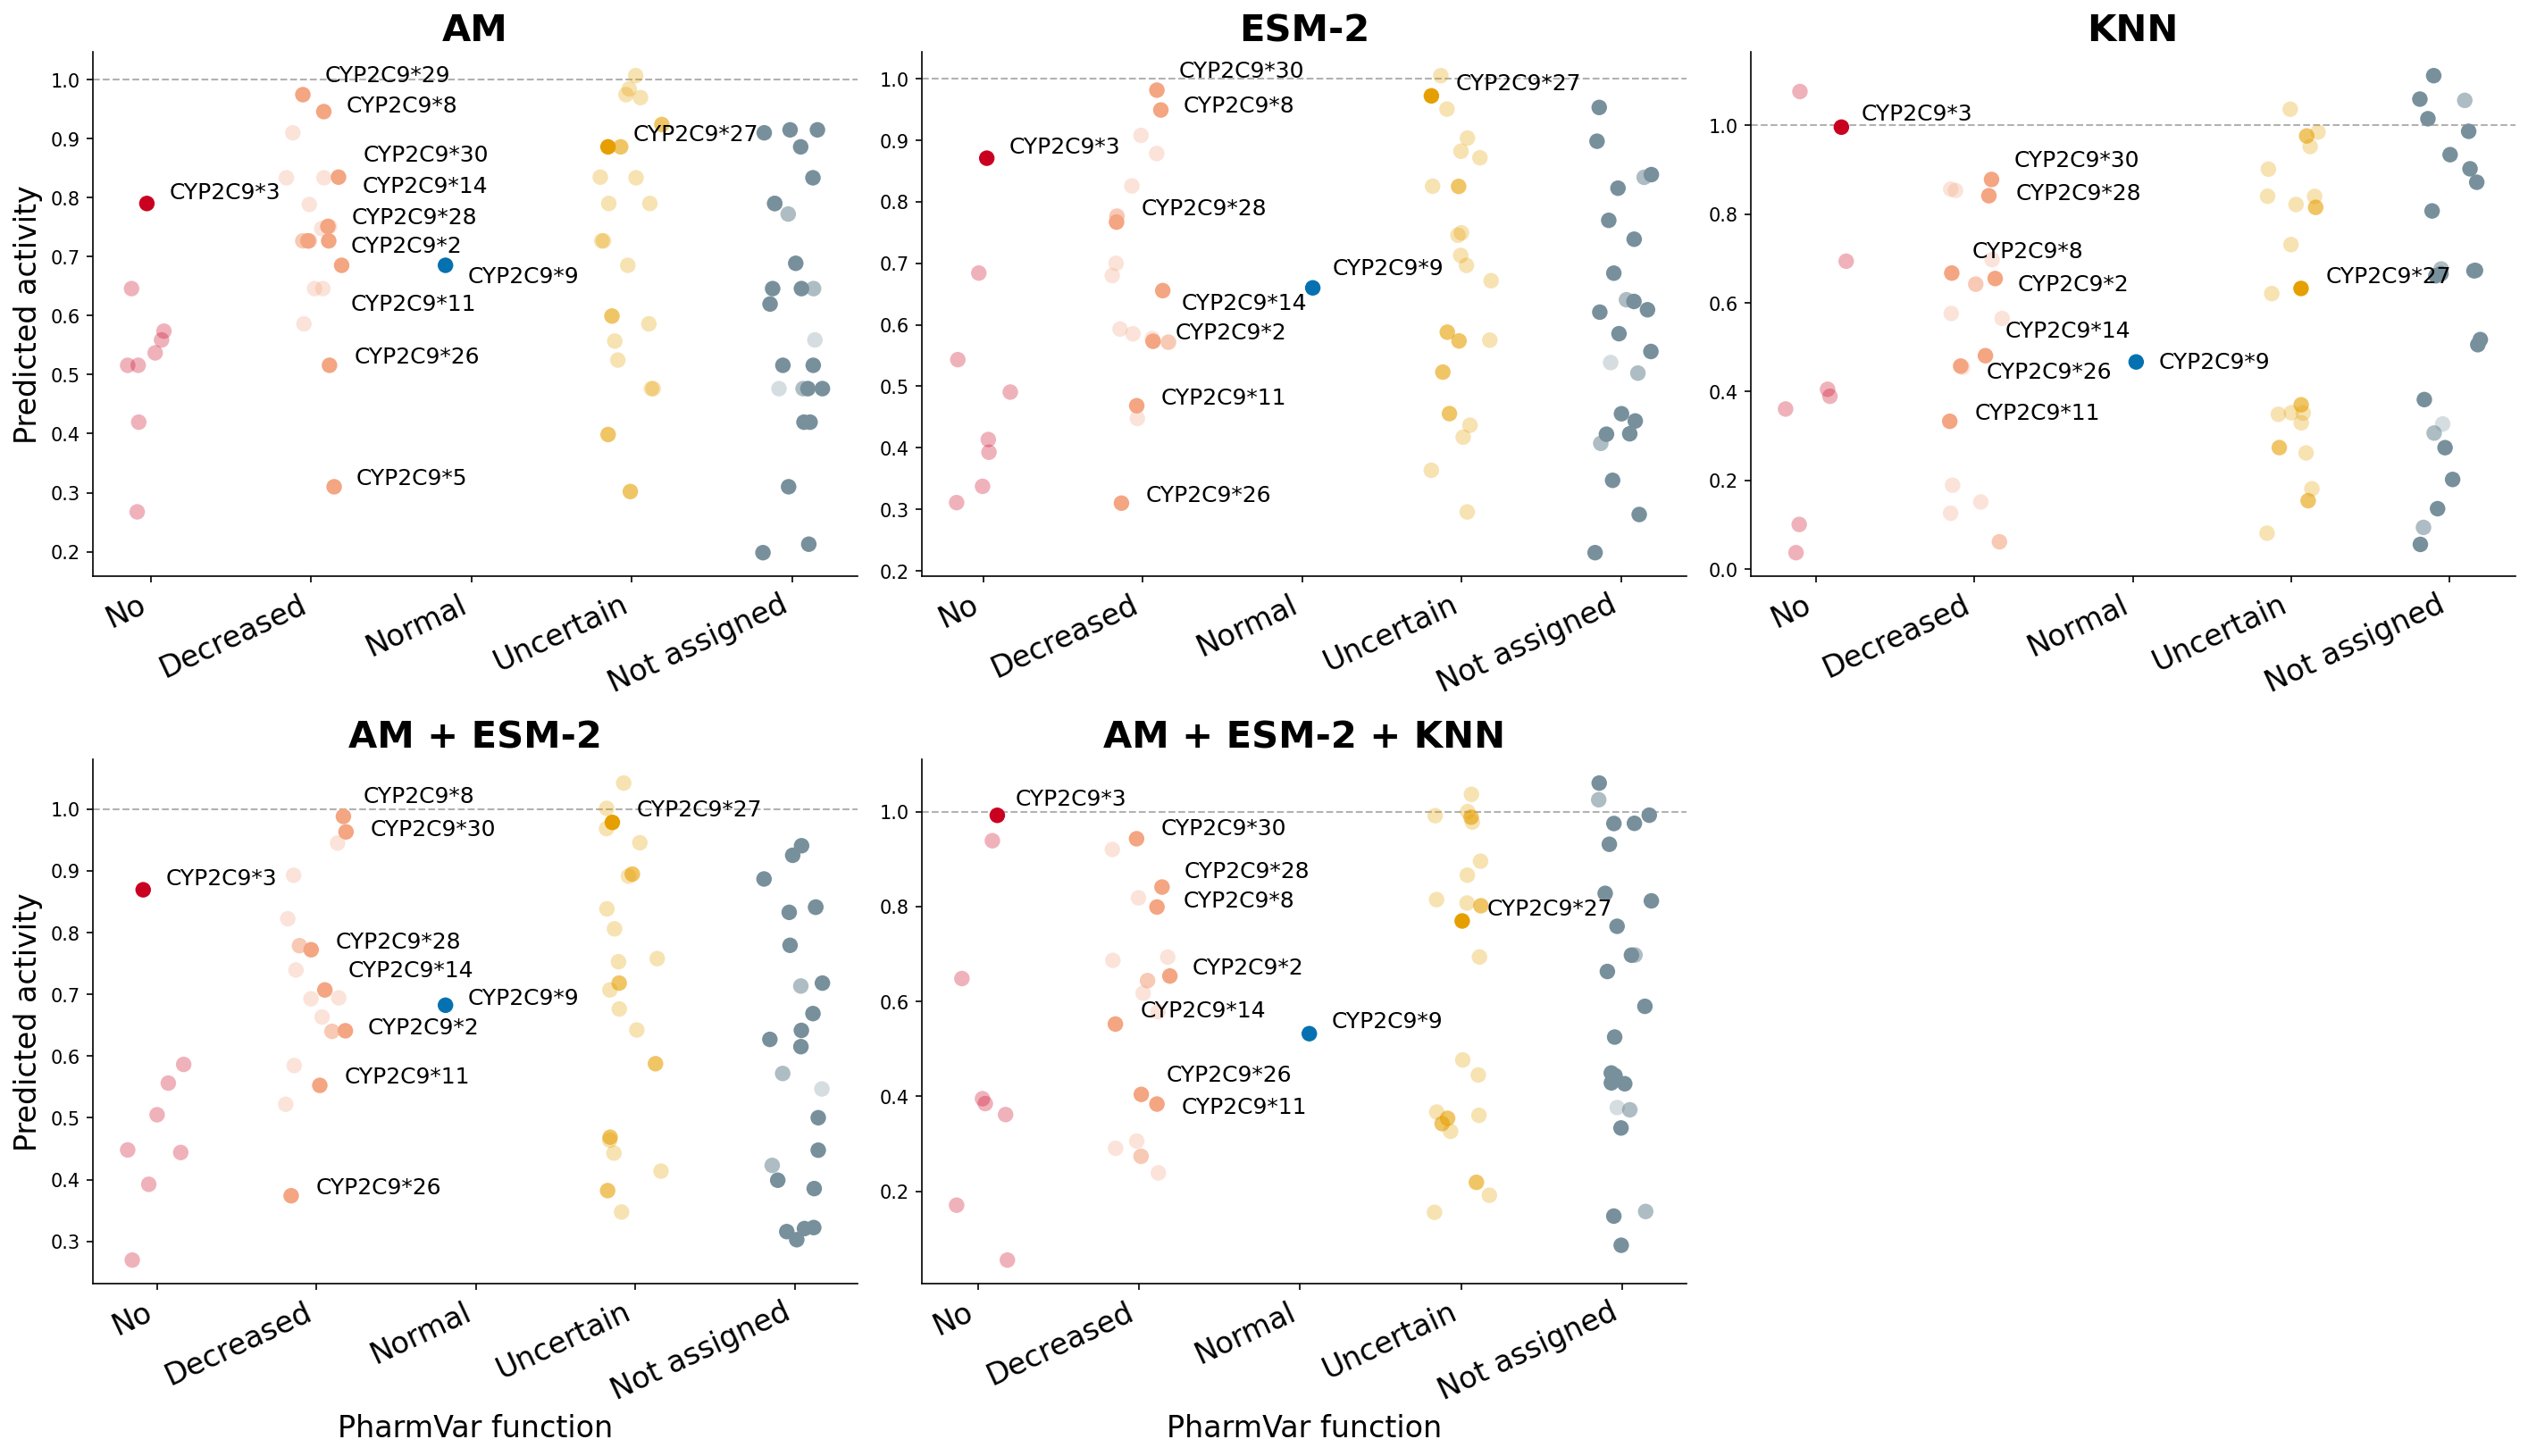

In [21]:
# Merge Unknown + Not Assigned into one plotting category
FUNC_MERGE = {'Function Not Assigned': 'Unknown / Not Assigned',
              'Unknown Function':      'Unknown / Not Assigned'}
pv['Function_plot'] = pv['Function'].replace(FUNC_MERGE)

PV_FUNC_ORDER = [
    'No Function', 'Decreased Function', 'Normal Function',
    'Uncertain Function', 'Unknown / Not Assigned',
]
PV_FUNC_COLORS = {
    'No Function':            '#CA0020',
    'Decreased Function':     '#F4A582',
    'Normal Function':        '#0571B0',
    'Uncertain Function':     '#E69F00',
    'Unknown / Not Assigned': '#78909C',
}
XLABEL_MAP = {'Unknown / Not Assigned': 'Not assigned'}   # x-axis display override
EVID_ALPHA = {'Definitive': 1.0, 'Moderate': 0.6, 'Limited': 0.3}

# Ordinal function scale for quantifying predicted-activity vs. PharmVar-label
# correlation (higher = more functional). Uncertain/Unknown/Not Assigned excluded.
FUNC_NUMERIC = {'No Function': 0, 'Decreased Function': 1, 'Normal Function': 2}
pv['func_numeric'] = pv['Function'].map(FUNC_NUMERIC)

# Reorder models: AM → ESM-2 → KNN → AM + ESM-2 → AM + ESM-2 + KNN
clean = lambda s: s.replace('(individual)', '').strip()
MODEL_ORDER = ['AM', 'ESM-2', 'KNN', 'AM + ESM-2', 'AM + ESM-2 + KNN']
pv_models_ordered = sorted(
    PV_MODELS,
    key=lambda cn: MODEL_ORDER.index(clean(cn[1])) if clean(cn[1]) in MODEL_ORDER else 99)


def plot_activity_by_pharmvar(ax, sub, pred_col, func_present, rng, label_fontsize=12):
    """Jittered scatter of predicted activity by PharmVar function label, colored by
    function and shaded by evidence level; labels Definitive-evidence alleles."""
    allele_pos = {}
    for evid, alpha in EVID_ALPHA.items():
        grp = sub[sub['Evidence Level'] == evid]
        if grp.empty:
            continue
        xs = np.array([func_present.index(f) for f in grp['Function_plot']], dtype=float)
        xs += rng.uniform(-0.2, 0.2, size=len(grp))
        ax.scatter(xs, grp[pred_col].values,
                   c=[PV_FUNC_COLORS[f] for f in grp['Function_plot']],
                   s=70, alpha=alpha, edgecolors='none', zorder=3)
        for xv, (_, row) in zip(xs, grp.iterrows()):      # remember true jittered position
            allele_pos[row['Allele']] = (xv, row[pred_col])

    # Label all Definitive-evidence points except the "Not assigned" column
    texts = []
    label_rows = sub[(sub['Evidence Level'] == 'Definitive') &
                     (sub['Function_plot'] != 'Unknown / Not Assigned')]
    for _, row in label_rows.iterrows():
        xv, yv = allele_pos.get(row['Allele'],
                                (func_present.index(row['Function_plot']), row[pred_col]))
        texts.append(ax.text(xv, yv, row['Allele'], fontsize=label_fontsize))
    adjust_text(texts, ax=ax, only_move={'text': 'y'}, expand_text=(1.05, 1.2))

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(range(len(func_present)))
    ax.set_xticklabels([XLABEL_MAP.get(f, f.replace(' Function', '')) for f in func_present],
                       fontsize=16, rotation=25, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Print Spearman ρ / p / n per model first ──────────────────────────────────
print('Spearman ρ: predicted activity vs ordinal PharmVar function label')
print('(No Function=0, Decreased Function=1, Normal Function=2;')
print(' Uncertain / Unknown / Not Assigned excluded)\n')
for pred_col, name in pv_models_ordered:
    ord_sub = pv.dropna(subset=['func_numeric', pred_col])
    if len(ord_sub) >= 3:
        rho, p = stats.spearmanr(ord_sub['func_numeric'], ord_sub[pred_col])
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {clean(name):<20}: rho={rho:+.3f}  p={p:.3e} {stars}  n={len(ord_sub)}')
    else:
        print(f'  {clean(name):<20}: insufficient data (n={len(ord_sub)})')
print()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes_flat = axes.flatten()
rng = np.random.default_rng(42)
ncols, n_used = 3, len(pv_models_ordered)

for ax_i, (pred_col, title) in enumerate(pv_models_ordered):
    ax = axes_flat[ax_i]
    sub = pv[pv[pred_col].notna()].copy()
    func_present = [f for f in PV_FUNC_ORDER if f in sub['Function_plot'].values]

    plot_activity_by_pharmvar(ax, sub, pred_col, func_present, rng)

    ax.set_ylabel('Predicted activity' if ax_i % ncols == 0 else '', fontsize=16)
    ax.set_xlabel('PharmVar function' if ax_i + ncols > n_used else '', fontsize=16)
    ax.set_title(clean(title), fontsize=20, fontweight='bold')

# 6th panel unused (only 5 models) -- function/evidence color key lives in the caption
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


Spearman ρ: predicted activity vs ordinal function label
(No Function=0, Decreased Function=1, Normal Function=2;
 Uncertain / Unknown / Function Not Assigned excluded)

  AM (individual):
    Definitive only           : rho=-0.305  p=0.362 ns  n=11
    Definitive + Moderate     : rho=-0.346  p=0.247 ns  n=13
    All known-function        : rho=+0.509  p=0.004 **  n=30

  ESM-2 (individual):
    Definitive only           : rho=-0.183  p=0.638 ns  n=9
    Definitive + Moderate     : rho=-0.202  p=0.551 ns  n=11
    All known-function        : rho=+0.399  p=0.039 *  n=27

  AM + ESM-2:
    Definitive only           : rho=-0.274  p=0.476 ns  n=9
    Definitive + Moderate     : rho=-0.270  p=0.423 ns  n=11
    All known-function        : rho=+0.489  p=0.010 **  n=27

  KNN (individual):
    Definitive only           : rho=-0.548  p=0.127 ns  n=9
    Definitive + Moderate     : rho=-0.472  p=0.143 ns  n=11
    All known-function        : rho=+0.070  p=0.728 ns  n=27

  AM + ESM-2 + KNN:
   

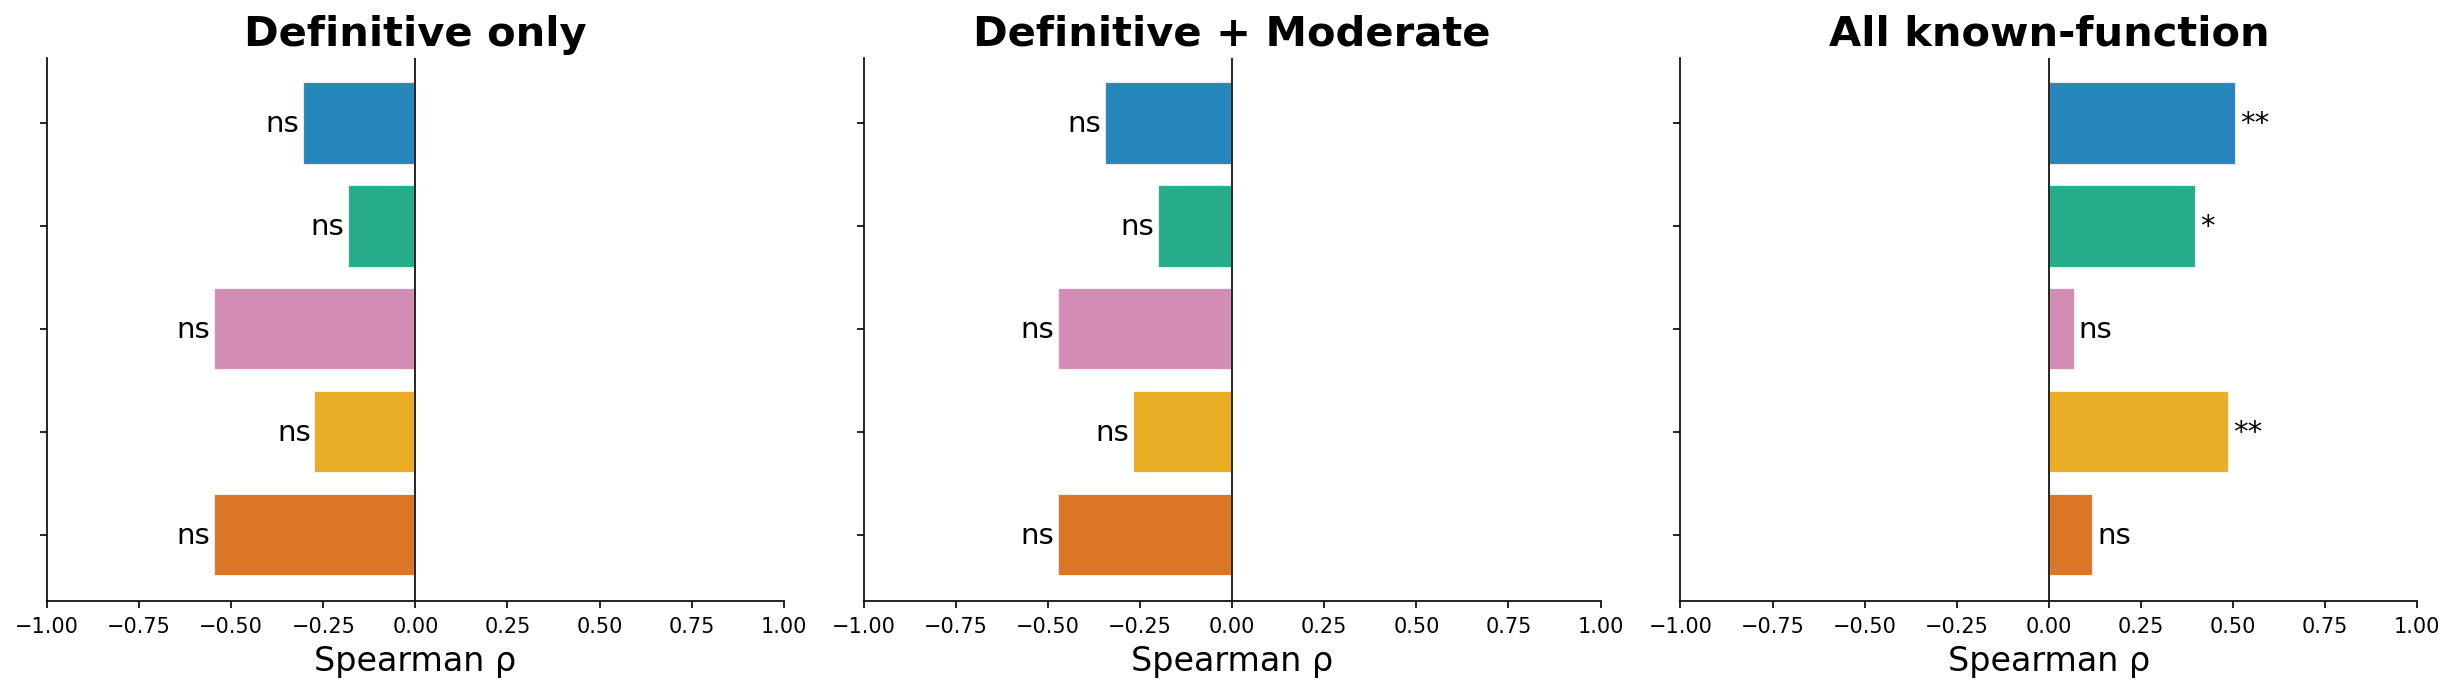

In [22]:
# FUNC_NUMERIC / pv['func_numeric'] already defined above (PharmVar figure cell)
EVID_RANK = {'Limited': 1, 'Moderate': 2, 'Definitive': 3}

pv['evid_rank'] = pv['Evidence Level'].map(EVID_RANK)

evidence_thresholds = [
    ('Definitive only',       3),
    ('Definitive + Moderate', 2),
    ('All known-function',    1),
]

print('Spearman ρ: predicted activity vs ordinal function label')
print('(No Function=0, Decreased Function=1, Normal Function=2;')
print(' Uncertain / Unknown / Function Not Assigned excluded)\n')

for col, name in PV_MODELS:
    print(f'  {name}:')
    for label, min_evid in evidence_thresholds:
        sub = pv[pv['evid_rank'] >= min_evid].dropna(subset=['func_numeric', col])
        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['func_numeric'], sub[col])
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'    {label:<26}: rho={r:+.3f}  p={p:.3f} {stars}  n={len(sub)}')
        else:
            print(f'    {label:<26}: insufficient data (n={len(sub)})')
    print()

# ── Bar chart: Spearman rho by evidence level threshold ───────────────────────
MODEL_ORDER = ['AM', 'ESM-2', 'KNN', 'AM + ESM-2', 'AM + ESM-2 + KNN']  # top → bottom
MODEL_COLOR = {
    'AM':                 '#0072B2',
    'ESM-2':              '#009E73',
    'KNN':                '#CC79A7',
    'AM + ESM-2':         '#E69F00',
    'AM + ESM-2 + KNN':   '#D55E00',
}
clean = lambda s: s.replace('(individual)', '').strip()

fig, axes = plt.subplots(1, len(evidence_thresholds),
                         figsize=(5.5 * len(evidence_thresholds), 5), sharey=True)

for ax, (label, min_evid) in zip(axes, evidence_thresholds):
    sub_all = pv[pv['evid_rank'] >= min_evid].dropna(subset=['func_numeric'])

    # collect results keyed by cleaned model name
    stats_by_model = {}
    for col, name in PV_MODELS:
        sub = sub_all.dropna(subset=[col])
        if len(sub) >= 3:
            r, p = stats.spearmanr(sub['func_numeric'], sub[col])
        else:
            r, p = 0.0, 1.0
        stats_by_model[clean(name)] = (r, p)

    # reorder to the desired top-to-bottom order
    model_names = [m for m in MODEL_ORDER if m in stats_by_model]
    r_vals = [stats_by_model[m][0] for m in model_names]
    p_vals = [stats_by_model[m][1] for m in model_names]
    colors = [MODEL_COLOR[m] for m in model_names]

    ys   = range(len(model_names))
    bars = ax.barh(list(ys), r_vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v, p in zip(bars, r_vals, p_vals):
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        yc = bar.get_y() + bar.get_height() / 2
        if v >= 0:
            ax.text(v + 0.01, yc, f'{stars}', va='center', ha='left', fontsize=14)
        else:
            ax.text(v - 0.01, yc, f'{stars}', va='center', ha='right', fontsize=14)

    ax.set_yticks(list(ys))
    ax.set_yticklabels([""]*5, fontsize=16)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman ρ', fontsize=16)
    ax.set_title(f'{label}',
                 fontsize=20, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].invert_yaxis()                  # shared y → AM at top … AM + ESM-2 + KNN at bottom

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

PharmVar variants with click-seq: 60

Model                   Spearman r         p     n
----------------------------------------------------
  AM (individual)            0.498     0.000    60
  ESM-2 (individual)         0.581     0.000    60
  AM + ESM-2                 0.568     0.000    60
  KNN (individual)           0.805     0.000    60
  AM + ESM-2 + KNN           0.819     0.000    60



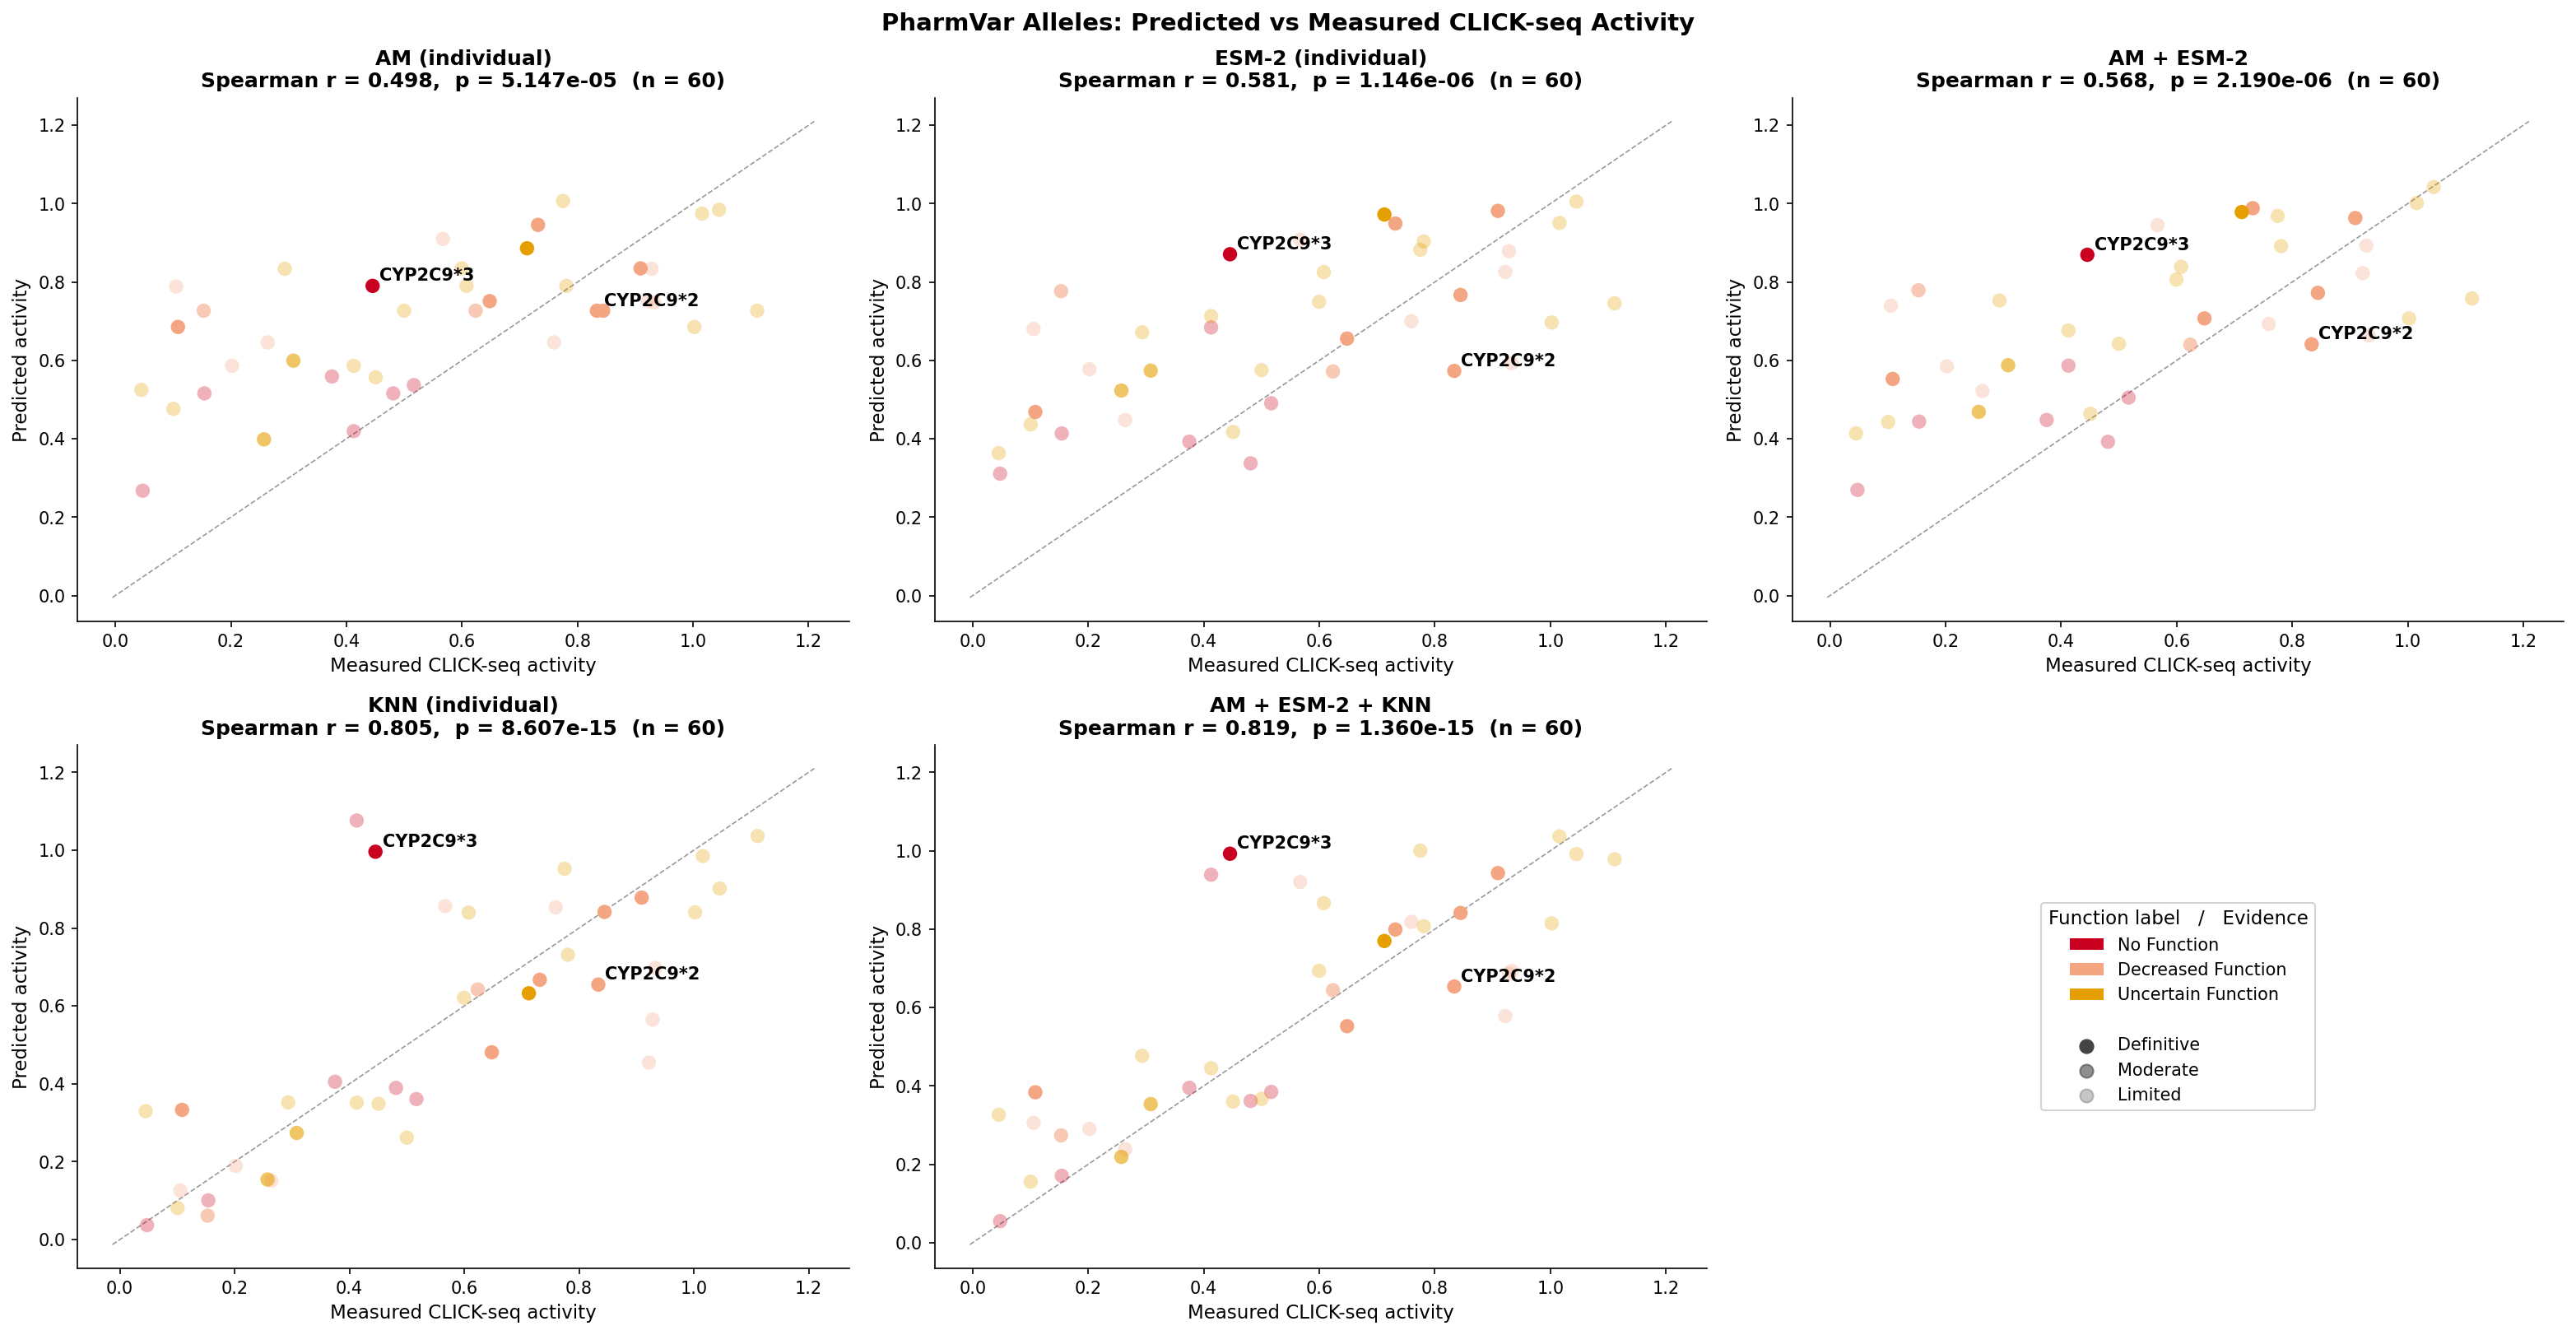

In [23]:
pv_click = pv[pv['click-seq_score'].notna()].drop_duplicates(['ref', 'pos', 'alt']).copy()
print(f'PharmVar variants with click-seq: {len(pv_click)}\n')

print(f'{"Model":<22}  {"Spearman r":>10}  {"p":>8}  {"n":>4}')
print('-' * 52)
for col, name in PV_MODELS:
    sub = pv_click[pv_click[col].notna()]
    r, p = stats.spearmanr(sub['click-seq_score'], sub[col])
    print(f'  {name:<20}  {r:>10.3f}  {p:>8.3f}  {len(sub):>4}')

print()
valid_models_pv = [(col, name) for col, name in PV_MODELS if pv_click[col].notna().any()]
ncols    = min(3, len(valid_models_pv))
nrows    = (len(valid_models_pv) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax_i, (pred_col, title) in enumerate(valid_models_pv):
    ax  = axes_flat[ax_i]
    sub = pv_click[pv_click[pred_col].notna()].copy()

    for func in PV_FUNC_ORDER:
        for evid, alpha in EVID_ALPHA.items():
            grp = sub[(sub['Function'] == func) & (sub['Evidence Level'] == evid)]
            if grp.empty: continue
            ax.scatter(grp['click-seq_score'], grp[pred_col],
                       color=PV_FUNC_COLORS[func],
                       s=70, alpha=alpha, edgecolors='none', zorder=3)

    for _, row in sub[sub['Allele'].isin({'CYP2C9*2', 'CYP2C9*3'})].iterrows():
        ax.annotate(row['Allele'], (row['click-seq_score'], row[pred_col]),
                    fontsize=10, xytext=(4, 3), textcoords='offset points', fontweight='bold')

    lo = min(sub['click-seq_score'].min(), sub[pred_col].min()) - 0.05
    hi = max(sub['click-seq_score'].max(), sub[pred_col].max()) + 0.05
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4)

    r, p = stats.spearmanr(sub['click-seq_score'], sub[pred_col])
    ax.set_title(f'{title}\nSpearman r = {r:.3f},  p = {p:.3e}  (n = {len(sub)})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Measured CLICK-seq activity', fontsize=11)
    ax.set_ylabel('Predicted activity', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend on last panel
ax_leg = axes_flat[len(valid_models_pv)]
ax_leg.axis('off')
func_present = [f for f in PV_FUNC_ORDER if f in pv_click['Function'].values]
func_h = [Patch(facecolor=PV_FUNC_COLORS[f], label=f) for f in func_present]
sep    = [Line2D([0], [0], color='none')]
evid_h = [ax_leg.scatter([], [], c='#444444', s=60, alpha=a, label=e)
          for e, a in EVID_ALPHA.items()]
ax_leg.legend(handles=func_h + sep + evid_h,
              labels=[f for f in func_present] + [''] + list(EVID_ALPHA.keys()),
              loc='center', fontsize=10,
              title='Function label   /   Evidence', title_fontsize=11)

for ax_i in range(len(valid_models_pv) + 1, nrows * ncols):
    axes_flat[ax_i].set_visible(False)

fig.suptitle('PharmVar Alleles: Predicted vs Measured CLICK-seq Activity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Comprehensive metrics: all 5 methods × ClinVar / PharmVar / DMS datasets
# ─────────────────────────────────────────────────────────────────────────────
def _clf_metrics(y_true, y_score, pos_higher=True):
    """Binary classification metrics; finds optimal threshold via Youden's J."""
    s = y_score if pos_higher else -y_score
    try:
        auroc = roc_auc_score(y_true, s)
        auprc = average_precision_score(y_true, s)
        fpr, tpr, thrs = roc_curve(y_true, s)
        opt   = np.argmax(tpr - fpr)
        y_hat = (s >= thrs[opt]).astype(int)
    except Exception:
        return {k: np.nan for k in ['AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']}
    return {
        'AUROC':     round(float(auroc), 3),
        'AUPRC':     round(float(auprc), 3),
        'Accuracy':  round(float(accuracy_score(y_true, y_hat)), 3),
        'Precision': round(float(precision_score(y_true, y_hat, zero_division=0)), 3),
        'Recall':    round(float(recall_score(y_true, y_hat, zero_division=0)), 3),
        'F1':        round(float(f1_score(y_true, y_hat, zero_division=0)), 3),
        'MCC':       round(float(matthews_corrcoef(y_true, y_hat)), 3),
    }


METHODS = {
    'AlphaMissense':    'pred_am',
    'ESM-2':            'pred_esm2',
    'KNN':              'pred_knn',
    'AM + ESM-2':       'pred_ensemble',
    'AM + ESM-2 + KNN': 'pred_ens_knn',
}

DMS_METHODS = {
    'AlphaMissense':    'oof_am_emb',
    'ESM-2':            'oof_esm_emb',
    'KNN':              'oof_knn_emb',
    'AM + ESM-2':       'oof_ens_emb',
    'AM + ESM-2 + KNN': 'oof_ens_knn',
}

# ── 1. ClinVar ────────────────────────────────────────────────────────────────
# Gold standard: B/LB = benign (0), LP/P = pathogenic (1); VUS excluded.
# Higher predicted activity → benign, so pos_higher=False for pathogenic as positive.
cv_eval = cv_pred[cv_pred['category'].isin(
    ['benign','likely_benign','likely_pathogenic','pathogenic'])].copy()
cv_eval['label'] = cv_eval['category'].isin(
    ['likely_pathogenic','pathogenic']).astype(int)

clinvar_rows = {}
for name, col in METHODS.items():
    sub = cv_eval.dropna(subset=[col])
    m   = _clf_metrics(sub['label'].values, sub[col].values, pos_higher=False)
    m['N'] = len(sub)
    clinvar_rows[name] = m

clinvar_metrics = (
    pd.DataFrame(clinvar_rows).T
      [['N','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']]
)
clinvar_metrics.index.name = 'Method'
print('=== ClinVar Metrics (B/LB=benign vs LP/P=pathogenic, VUS excluded) ===')
print(f'  Total N = {len(cv_eval)}  '
      f'(benign={int((cv_eval.label==0).sum())}, pathogenic={int((cv_eval.label==1).sum())})')
print(clinvar_metrics.to_string())

# ── 2. PharmVar ───────────────────────────────────────────────────────────────
# Gold standard: Normal Function = 1, Decreased/No Function = 0; uncertain excluded.
# Higher predicted activity → Normal Function (positive), so pos_higher=True.
pv_eval = pv[pv['Function'].isin(
    ['No Function','Decreased Function','Normal Function'])].copy()
pv_eval['label'] = (pv_eval['Function'] == 'Normal Function').astype(int)

pharmvar_rows = {}
for name, col in METHODS.items():
    sub = pv_eval.dropna(subset=[col])
    m   = _clf_metrics(sub['label'].values, sub[col].values, pos_higher=True)
    pv_ord = pv.dropna(subset=[col, 'func_numeric'])
    rho, _ = stats.spearmanr(pv_ord[col], pv_ord['func_numeric'])
    m['Spearman_rho'] = round(float(rho), 3)
    m['N'] = len(sub)
    pharmvar_rows[name] = m

pharmvar_metrics = (
    pd.DataFrame(pharmvar_rows).T
      [['N','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC','Spearman_rho']]
)
pharmvar_metrics.index.name = 'Method'
print('\n=== PharmVar Metrics (Normal Function vs Decreased/No Function) ===')
print(f'  Total N = {len(pv_eval)}  '
      f'(normal={int((pv_eval.label==1).sum())}, decreased/no={int((pv_eval.label==0).sum())})')
print(pharmvar_metrics.to_string())

# ── 3. DMS / CLICK-seq ────────────────────────────────────────────────────────
# Gold standard: continuous click-seq_score (OOF predictions on embedding subset).
# Regression: Spearman, Pearson, RMSE.
# Binary split at median: above-median activity = 1 (functional), below = 0.
dms_median = emb_train['click-seq_score'].median()

dms_rows = {}
for name, col in DMS_METHODS.items():
    sub    = emb_train.dropna(subset=[col, 'click-seq_score'])
    y_cont = sub['click-seq_score'].values
    y_pred = sub[col].values
    rho, _ = stats.spearmanr(y_pred, y_cont)
    r, _   = stats.pearsonr(y_pred, y_cont)
    rmse   = float(np.sqrt(np.mean((y_pred - y_cont) ** 2)))
    y_bin  = (y_cont >= dms_median).astype(int)
    m      = _clf_metrics(y_bin, y_pred, pos_higher=True)
    m.update({
        'Spearman_rho': round(float(rho), 3),
        'Pearson_r':    round(float(r), 3),
        'RMSE':         round(float(rmse), 4),
        'N': len(sub),
    })
    dms_rows[name] = m

dms_metrics = (
    pd.DataFrame(dms_rows).T
      [['N','Spearman_rho','Pearson_r','RMSE','AUROC','AUPRC','Accuracy','Precision','Recall','F1','MCC']]
)
dms_metrics.index.name = 'Method'
print('\n=== DMS / CLICK-seq Metrics (OOF on embedding subset) ===')
print(f'  N = {len(emb_train.dropna(subset=["click-seq_score"]))}, '
      f'binary threshold = median ({dms_median:.4f})')
print(dms_metrics.to_string())


=== ClinVar Metrics (B/LB=benign vs LP/P=pathogenic, VUS excluded) ===
  Total N = 8  (benign=7, pathogenic=1)
                    N  AUROC  AUPRC  Accuracy  Precision  Recall     F1    MCC
Method                                                                        
AlphaMissense     8.0  0.286  0.167     0.375      0.167     1.0  0.286  0.218
ESM-2             7.0  0.333  0.200     0.429      0.200     1.0  0.333  0.258
KNN               7.0  0.000  0.143     0.857      0.000     0.0  0.000  0.000
AM + ESM-2        7.0  0.333  0.200     0.429      0.200     1.0  0.333  0.258
AM + ESM-2 + KNN  7.0  0.167  0.167     0.286      0.167     1.0  0.286  0.167

=== PharmVar Metrics (Normal Function vs Decreased/No Function) ===
  Total N = 30  (normal=1, decreased/no=29)
                     N  AUROC  AUPRC  Accuracy  Precision  Recall     F1    MCC  Spearman_rho
Method                                                                                       
AlphaMissense     30.0  0.466  0.05